# SLDS Step 3: Trajectory Sampling

**Goal**: Generate synthetic flight trajectories using the trained SLDS model.

**Sampling Process**:

1. **Sample initial state** $x_0 \sim \mathcal{N}(\mu_0, \Sigma_0)$ and mode $z_0$
2. **For each timestep** $t = 1, ..., T$:
   - Sample mode: $z_t \sim \text{Discrete}(z_{t-1}, \pi)$
   - Sample state: $x_t \sim \mathcal{N}(A_{z_t} x_{t-1} + b_{z_t}, Q_{z_t})$
3. **Integrate** to get XY trajectory and altitude profile

## Setup and Load Trained Model

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Import pyslds
import sys
sys.path.insert(0, '/home/fusg/VT_2/pyslds-master')
import pyslds

# Plotting
plt.rcParams.update({
    'font.family': 'cmr10',
    'font.size': 13,
    'figure.dpi': 150
})

print(f"pyslds loaded from: {pyslds.__file__}")

pyslds loaded from: /home/fusg/VT_2/pyslds-master/pyslds/__init__.py


/home/fusg/.venv_slds/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load trained SLDS model
with open("/store/fusg/VT2/slds/trained_slds_model_v2.pkl", 'rb') as f:
    trained_data = pickle.load(f)

model = trained_data['model']
metadata = trained_data['metadata']
training_info = trained_data['training_info']

K_modes = metadata['K_modes']
D_obs = metadata['D_obs']
feature_names = metadata['feature_names']
N_phases = metadata.get('N_phases', None)

print(f"Loaded trained SLDS model:")
print(f"  - K = {K_modes} modes")
print(f"  - D_obs = {D_obs}")
print(f"  - Trained on {training_info['n_flights_trained']} flights")
final_ll = training_info.get('final_ll', None)
if final_ll is not None:
    print(f"  - Final log-likelihood: {final_ll:.2f}")

print(f"\nFeatures: {feature_names}")
if N_phases is not None:
    print(f"Phases: {list(metadata.get('phase_mapping', {}).keys())}")

Loaded trained SLDS model:
  - K = 5 modes
  - D_obs = 4
  - Trained on 1000 flights
  - Final log-likelihood: 30378884.43

Features: ['vx', 'vy', 'vertical_rate', 'altitude']
Phases: ['CLIMB', 'CRUISE', 'DESCENT', 'LEVEL', 'NA']


## Load Feature Scaler

In [3]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Load the scaler used during data preparation (StandardScaler as of SLDS_01)
scaler_path = metadata.get('scaler_path', '/store/fusg/VT2/slds/feature_scaler.pkl')

with open(scaler_path, 'rb') as f:
    scaler = pickle.load(f)

print(f"Loaded feature scaler from: {scaler_path}")
print(f"  Scaler class: {type(scaler).__name__}")

# Print diagnostic stats per feature depending on scaler type
if isinstance(scaler, StandardScaler) or (hasattr(scaler, 'mean_') and hasattr(scaler, 'scale_')):
    means = getattr(scaler, 'mean_', None)
    scales = getattr(scaler, 'scale_', None)
    print("  Using StandardScaler statistics:")
    print(f"    means: {np.round(means, 3) if means is not None else None}")
    print(f"    scales: {np.round(scales, 3) if scales is not None else None}")
    
    if means is not None and scales is not None and 'feature_names' in globals():
        print("\nFeature mapping (for reference):")
        for i, name in enumerate(feature_names):
            m = means[i] if i < len(means) else None
            s = scales[i] if i < len(scales) else None
            print(f"  [{i}] {name:20s}: mean={m:10.3f}  scale={s:10.3f}")
elif isinstance(scaler, MinMaxScaler) or (hasattr(scaler, 'data_min_') and hasattr(scaler, 'data_max_')):
    mins = getattr(scaler, 'data_min_', None)
    maxs = getattr(scaler, 'data_max_', None)
    ranges = getattr(scaler, 'data_range_', None)
    print("  Using MinMaxScaler statistics:")
    print(f"    mins: {np.round(mins, 3) if mins is not None else None}")
    print(f"    maxs: {np.round(maxs, 3) if maxs is not None else None}")
    print(f"    ranges: {np.round(ranges, 3) if ranges is not None else None}")

    if mins is not None and maxs is not None and ranges is not None and 'feature_names' in globals():
        print("\nFeature mapping (for reference):")
        for i, name in enumerate(feature_names):
            mn = mins[i] if i < len(mins) else None
            mx = maxs[i] if i < len(maxs) else None
            rg = ranges[i] if i < len(ranges) else None
            print(f"  [{i}] {name:20s}: min={mn:10.3f}  max={mx:10.3f}  range={rg:10.3f}")
else:
    print("  Unknown scaler type. Proceeding without detailed diagnostics.")

Loaded feature scaler from: /store/fusg/VT2/slds/feature_scaler_v2.pkl
  Scaler class: StandardScaler
  Using StandardScaler statistics:
    means: [ 3.2490000e+00 -2.5700000e-01  9.7000000e-02  3.3824518e+04]
    scales: [1.512940e+02 1.696230e+02 3.429000e+00 4.795724e+03]

Feature mapping (for reference):
  [0] vx                  : mean=     3.249  scale=   151.294
  [1] vy                  : mean=    -0.257  scale=   169.623
  [2] vertical_rate       : mean=     0.097  scale=     3.429
  [3] altitude            : mean= 33824.518  scale=  4795.724


/home/fusg/.venv_slds/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Sample Initial State

**Initial State Distribution**: Learned from first timestep of each training flight.

**pyslds stores**:
- `init_dynamics_distns[k]`: Initial state distribution for mode $k$
- Mean $\mu_0^{(k)}$ and covariance $\Sigma_0^{(k)}$

**Procedure**:
1. Choose initial mode $z_0$
2. Sample $x_0 \sim \mathcal{N}(\mu_0^{(z_0)}, \Sigma_0^{(z_0)})$

In [4]:
def sample_initial_state(model, initial_mode, rng=np.random.default_rng()):
    """
    Sample initial state x_0 from the learned initial distribution.
    
    Args:
        model: Trained pyslds model
        initial_mode: Integer mode index z_0
        rng: NumPy random generator
    
    Returns:
        x_0: Initial state vector (D_latent,)
    """
    # Get initial distribution for this mode
    init_distn = model.init_dynamics_distns[initial_mode]
    
    # Sample from Gaussian: x_0 ~ N(mu_0, Sigma_0)
    mu_0 = init_distn.mu
    Sigma_0 = init_distn.sigma
    
    x_0 = rng.multivariate_normal(mu_0, Sigma_0)
    
    return x_0

# Example: Sample initial state for mode 0 (cluster 0, altitude bin 0)
rng = np.random.default_rng(seed=42)
initial_mode = 0
x_0 = sample_initial_state(model, initial_mode, rng=rng)

print(f"\nSampled initial state for mode {initial_mode}:")
for i, (name, val) in enumerate(zip(feature_names, x_0)):
    print(f"  {name}: {val:.3f}")


Sampled initial state for mode 0:
  vx: -0.377
  vy: -0.112
  vertical_rate: 0.598
  altitude: 0.375


## Forward Sampling: Generate Trajectory

**Generative Model**:

$$
x_t = A_{z_t} x_{t-1} + b_{z_t} + w_t, \quad w_t \sim \mathcal{N}(0, Q_{z_t})
$$

**Mode Dynamics**: For simplicity, we assume **fixed mode** (no mode switching during trajectory). This is appropriate for:
- Short trajectories (~1-2 minutes)
- Constant flight phase (all CLIMB, all CRUISE, or all DESCENT)

**Extension**: To allow mode switching (e.g., CLIMB → CRUISE), sample $z_t$ from transition probabilities (requires learning transition matrix in SLDS).

**Cross-reference to DBN** (from `Sampling.ipynb`):
- DBN: `generate_time_series_from_initial()` with discrete transitions
- SLDS: Direct Gaussian sampling (smoother, no resampling heuristics)


In [5]:
def sample_trajectory_slds(
    model, 
    x_0, 
    mode, 
    T=60, 
    rng=np.random.default_rng(),
    scaler=None
):
    """
    Sample a trajectory from SLDS model using forward simulation.
    
    Args:
        model: Trained pyslds model
        x_0: Initial state (D_latent,) IN NORMALIZED SPACE if scaler provided
        mode: Mode index (assumed constant)
        T: Number of timesteps
        rng: Random generator
        scaler: StandardScaler for inverse transform (None = return normalized values)
    
    Returns:
        trajectory: Array of shape (T, D_latent) in PHYSICAL UNITS if scaler provided
    """
    D = len(x_0)
    trajectory = np.zeros((T, D))
    trajectory[0] = x_0
    
    # Get dynamics for this mode
    dynamics = model.dynamics_distns[mode]
    A = dynamics.A
    # Handle missing bias term (fallback to zeros if not present)
    b = dynamics.b if hasattr(dynamics, 'b') else np.zeros(D)
    Q = dynamics.sigma
    
    # Forward simulate IN NORMALIZED SPACE
    for t in range(1, T):
        # Deterministic part: A * x_{t-1} + b
        x_mean = A @ trajectory[t-1] + b
        
        # Stochastic part: sample noise from N(0, Q)
        noise = rng.multivariate_normal(np.zeros(D), Q)
        
        # Next state
        trajectory[t] = x_mean + noise
    
    # Inverse transform to physical units if scaler provided
    if scaler is not None:
        trajectory = scaler.inverse_transform(trajectory)
    
    return trajectory

def sample_trajectory_slds_with_switching(
    model, 
    x_0, 
    initial_mode, 
    T=60, 
    rng=np.random.default_rng(),
    scaler=None
):
    """
    Sample trajectory WITH mode switching using learned transition matrix.
    
    Args:
        model: Trained pyslds model
        x_0: Initial state (D_latent,) IN NORMALIZED SPACE if scaler provided
        initial_mode: Starting mode index
        T: Number of timesteps
        rng: Random generator
        scaler: StandardScaler for inverse transform (None = return normalized values)
    
    Returns:
        trajectory: Array of shape (T, D_latent) in PHYSICAL UNITS if scaler provided
        mode_sequence: Array of shape (T,) with mode indices
    """
    D = len(x_0)
    trajectory = np.zeros((T, D))
    mode_sequence = np.zeros(T, dtype=int)
    
    trajectory[0] = x_0
    mode_sequence[0] = initial_mode
    
    # Get transition probabilities from trained model
    trans_matrix = model.trans_distn.trans_matrix  # Shape: (K, K)
    
    for t in range(1, T):
        # Sample next mode from transition probabilities
        prev_mode = mode_sequence[t-1]
        mode_probs = trans_matrix[prev_mode, :]
        mode_sequence[t] = rng.choice(model.num_states, p=mode_probs)
        
        # Get dynamics for current mode
        current_mode = mode_sequence[t]
        dynamics = model.dynamics_distns[current_mode]
        A = dynamics.A
        # Handle missing bias term (fallback to zeros if not present)
        b = dynamics.b if hasattr(dynamics, 'b') else np.zeros(D)
        Q = dynamics.sigma
        
        # Forward simulate with current mode's dynamics IN NORMALIZED SPACE
        x_mean = A @ trajectory[t-1] + b
        noise = rng.multivariate_normal(np.zeros(D), Q)
        trajectory[t] = x_mean + noise
    
    # Inverse transform to physical units if scaler provided
    if scaler is not None:
        trajectory = scaler.inverse_transform(trajectory)
    
    return trajectory, mode_sequence

# Example: Generate one trajectory (fixed mode) WITH inverse transform
T = 60  # 60 seconds (1 minute)
traj = sample_trajectory_slds(model, x_0, mode=initial_mode, T=T, rng=rng, scaler=scaler)

print(f"\nGenerated trajectory (FIXED mode): shape {traj.shape}")
print(f"  Time: {T} seconds")
print(f"  Mode: {initial_mode} (fixed)")
print(f"  ⚠️  Trajectory is in PHYSICAL UNITS (inverse-transformed)")
print(f"\nFinal state (t={T}):")
for name, val in zip(feature_names, traj[-1]):
    print(f"  {name}: {val:.3f}")

# Example: Generate trajectory WITH mode switching
print("\n" + "="*60)
print("Trajectory WITH mode switching:")
traj_switch, modes_switch = sample_trajectory_slds_with_switching(
    model, x_0, initial_mode=initial_mode, T=T, rng=rng, scaler=scaler
)

num_switches = np.sum(modes_switch[1:] != modes_switch[:-1])
unique_modes = np.unique(modes_switch)
print(f"  Switches: {num_switches} mode changes in {T} seconds")
print(f"  Unique modes visited: {unique_modes.tolist()}")


Generated trajectory (FIXED mode): shape (60, 4)
  Time: 60 seconds
  Mode: 0 (fixed)
  ⚠️  Trajectory is in PHYSICAL UNITS (inverse-transformed)

Final state (t=60):
  vx: -130.771
  vy: -212.325
  vertical_rate: -17.161
  altitude: 33793.026

Trajectory WITH mode switching:
  Switches: 6 mode changes in 60 seconds
  Unique modes visited: [0, 1, 4]


## DIAGNOSTIC: Check Dynamics Stability

**Problem**: Trajectories are exploding (values ~10³⁰).

**Root Cause**: Some A matrices have eigenvalues > 1, causing exponential growth.

**Fix Options**:
1. **Stronger prior** on A matrices during training (force near-identity)
2. **Filter out unstable modes** (only use modes with all eigenvalues < 1)
3. **Post-process A matrices** to clip/normalize eigenvalues

Let's first diagnose which modes are unstable:

In [6]:
# Check stability of all learned dynamics matrices
print("="*70)
print("DYNAMICS STABILITY ANALYSIS")
print("="*70)

unstable_modes = []
stable_modes = []

for k in range(K_modes):
    A_k = model.dynamics_distns[k].A
    eigenvalues = np.linalg.eigvals(A_k)
    max_eigenvalue = np.max(np.abs(eigenvalues))
    
    if max_eigenvalue > 1.0:
        unstable_modes.append((k, max_eigenvalue))
    else:
        stable_modes.append((k, max_eigenvalue))

print(f"\nStable modes (max |λ| ≤ 1.0): {len(stable_modes)}/{K_modes}")
print(f"Unstable modes (max |λ| > 1.0): {len(unstable_modes)}/{K_modes}")

if unstable_modes:
    print("\n⚠️  UNSTABLE MODES:")
    unstable_modes.sort(key=lambda x: x[1], reverse=True)
    for k, max_eig in unstable_modes[:10]:  # Show worst 10
        print(f"  Mode {k:2d}: max |λ| = {max_eig:.3f}")
        
    print("\n💡 **SOLUTION**: Use only stable modes for sampling, OR retrain with stronger priors.")

if stable_modes:
    print("\n✓ STABLE MODES (safe to use for sampling):")
    for k, max_eig in stable_modes[:10]:  # Show first 10
        print(f"  Mode {k:2d}: max |λ| = {max_eig:.3f}")
    
    # Pick a stable mode for demonstration
    best_mode = min(stable_modes, key=lambda x: abs(x[1] - 0.95))[0]
    print(f"\n✓ Recommended mode for stable sampling: Mode {best_mode}")
else:
    print("\n⚠️  NO STABLE MODES FOUND!")
    print("   This indicates a fundamental training problem.")
    print("   Need to retrain with much stronger dynamics priors.")

DYNAMICS STABILITY ANALYSIS

Stable modes (max |λ| ≤ 1.0): 2/5
Unstable modes (max |λ| > 1.0): 3/5

⚠️  UNSTABLE MODES:
  Mode  3: max |λ| = 1.001
  Mode  1: max |λ| = 1.000
  Mode  4: max |λ| = 1.000

💡 **SOLUTION**: Use only stable modes for sampling, OR retrain with stronger priors.

✓ STABLE MODES (safe to use for sampling):
  Mode  0: max |λ| = 0.997
  Mode  2: max |λ| = 0.990

✓ Recommended mode for stable sampling: Mode 2


## Visualize Single Trajectory

**Plot**: Time series of each state variable (v, v_dot, psi_dot, h_dot)

**Expected behavior**:
- `v` (groundspeed): Should vary around mean cruise speed (~230-250 m/s)
- `v_dot` (acceleration): Should oscillate around 0 (small thrust adjustments)
- `psi_dot` (turn rate): Should be near 0 for straight flight, with occasional turns
- `h_dot` (vertical rate): Should be near 0 for level cruise

/tmp/ipykernel_2939763/2762731754.py:2: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
/tmp/ipykernel_2939763/2762731754.py:20: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) cmr10.
  plt.tight_layout()
/home/fusg/.venv_slds/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)
/home/fusg/.venv_slds/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) cmr10.
  fig.canvas.print_figure(bytes_io, **kw)


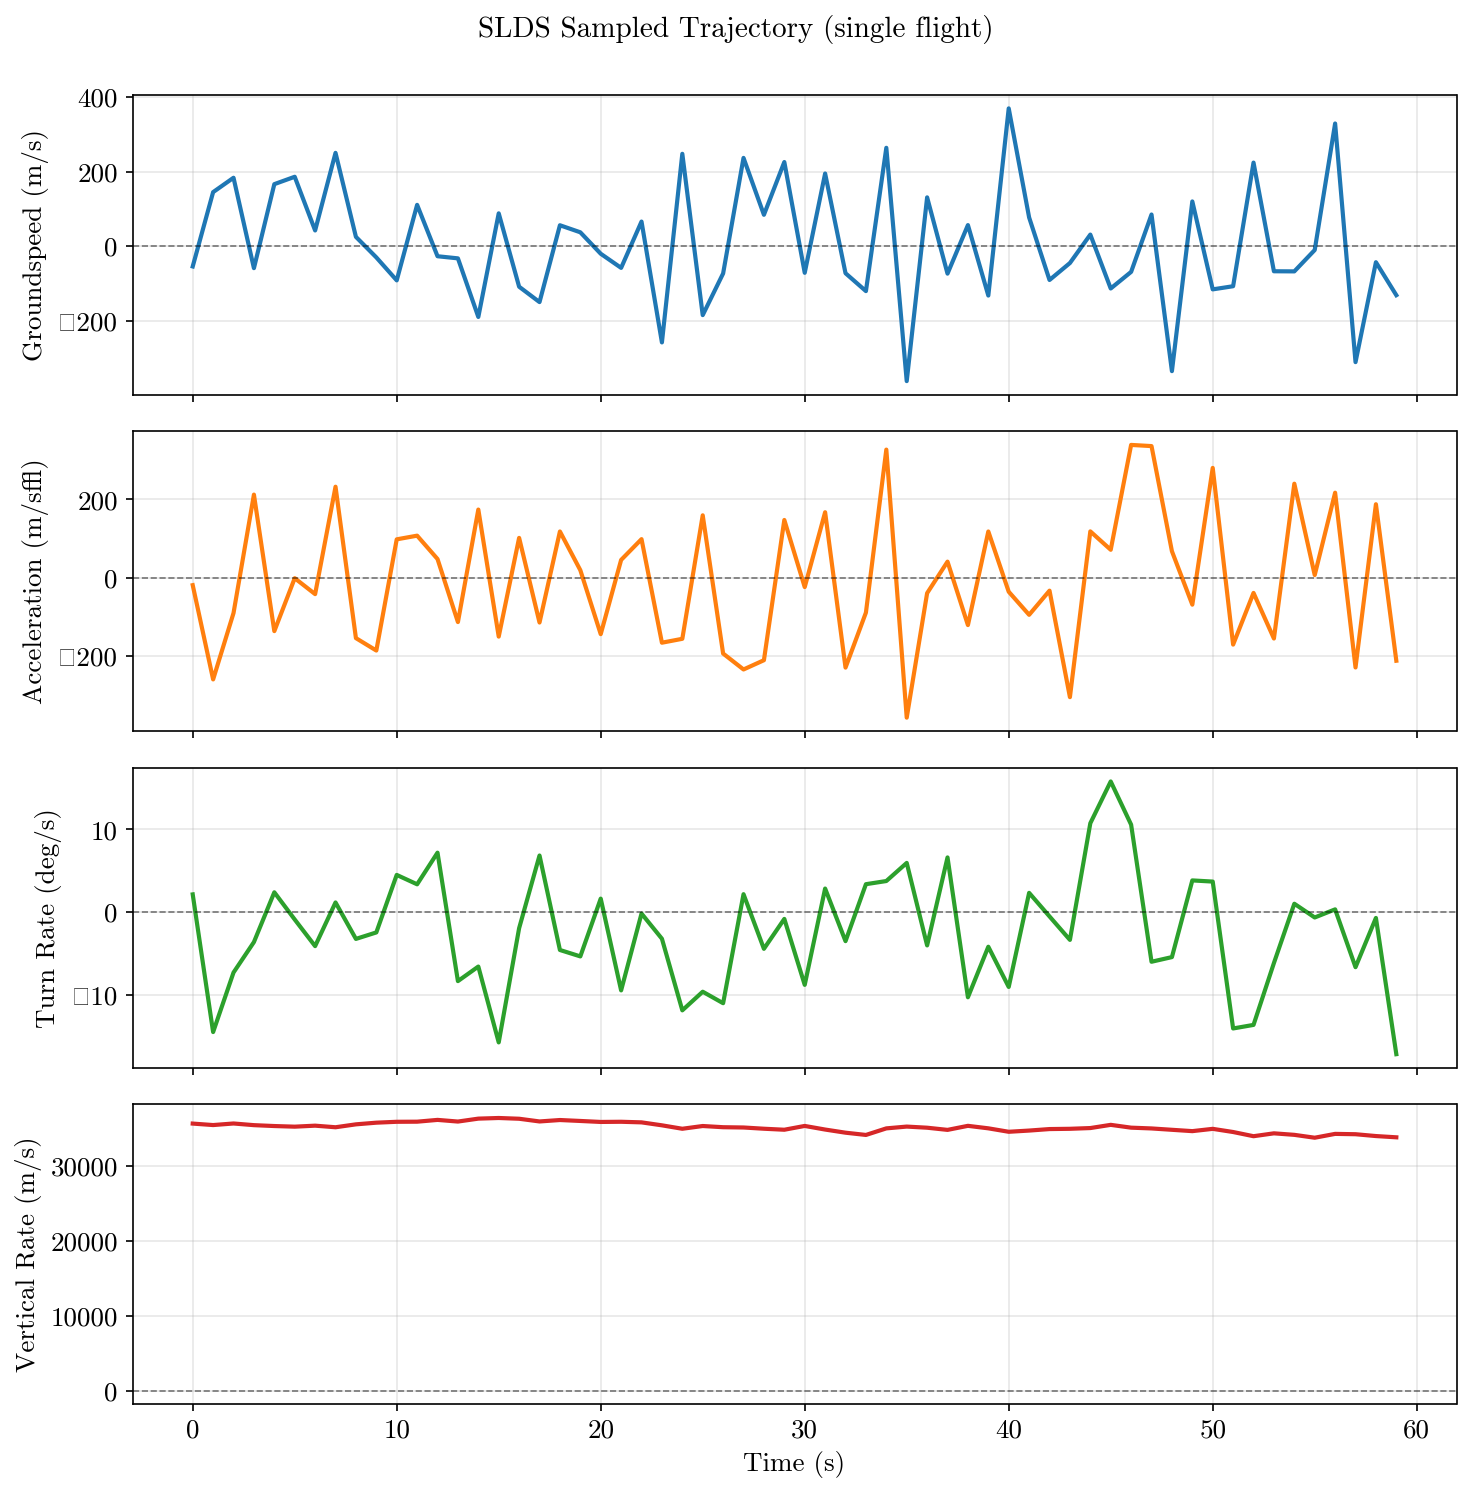

In [7]:
# Plot trajectory time series
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
time = np.arange(T)

titles = [
    'Groundspeed (m/s)',
    'Acceleration (m/s²)',
    'Turn Rate (deg/s)',
    'Vertical Rate (m/s)'
]

for i, (ax, title) in enumerate(zip(axes, titles)):
    ax.plot(time, traj[:, i], linewidth=2, color=f'C{i}')
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)

axes[-1].set_xlabel('Time (s)')
plt.suptitle('SLDS Sampled Trajectory (single flight)', y=0.995, fontsize=14)
plt.tight_layout()
plt.show()

## Integrate to XY Trajectory

**From kinematic features to spatial track**:

Given:
- $v_t$: groundspeed (m/s)
- $\dot{\psi}_t$: turn rate (deg/s)
- $\dot{h}_t$: vertical rate (m/s)

Integrate:
1. **Heading**: $\psi_t = \psi_{t-1} + \dot{\psi}_{t-1} \cdot \Delta t \cdot (\pi/180)$
2. **Position**: 
   - $x_t = x_{t-1} + v_t \cos(\psi_t) \cdot \Delta t$
   - $y_t = y_{t-1} + v_t \sin(\psi_t) \cdot \Delta t$
3. **Altitude**: $h_t = h_{t-1} + \dot{h}_{t-1} \cdot \Delta t$

In [18]:
def integrate_trajectory(
    traj, 
    dt=1.0, 
    initial_heading=0.0
):
    """
    Integrate SLDS trajectory to XY coordinates.

    Supports two feature layouts:
    - 4D: [vx, vy, vertical_rate, altitude]
    - 5D: [v, v_dot, psi_dot, vertical_rate, altitude]

    Args:
        traj: (T, D) array where D ∈ {4,5}
        dt: Timestep (seconds)
        initial_heading: Initial heading (radians); used only for 5D path

    Returns:
        dict with keys: 'time', 'x', 'y', 'heading', 'altitude', 'groundspeed', 'vertical_rate'
    """
    traj = np.asarray(traj)
    if traj.ndim != 2 or traj.shape[1] not in (4, 5):
        raise ValueError(f"traj must be (T,4) or (T,5); got shape {traj.shape}")

    T, D = traj.shape
    time = np.arange(T) * dt

    # Initialize outputs
    x = np.zeros(T)
    y = np.zeros(T)
    heading = np.zeros(T)

    if D == 5:
        # 5D legacy layout: [v, a, psi_dot_deg_s, h_dot_m_s, altitude_ft]
        v = traj[:, 0]           # m/s
        psi_dot = traj[:, 2]     # deg/s
        h_dot = traj[:, 3]       # m/s
        altitude = traj[:, 4]    # ft (already absolute altitude)

        heading[0] = initial_heading
        for t in range(1, T):
            # Update heading from turn rate (deg/s → rad/s)
            heading[t] = heading[t-1] + psi_dot[t-1] * (np.pi / 180.0) * dt
            # Advance position
            x[t] = x[t-1] + v[t] * np.cos(heading[t]) * dt
            y[t] = y[t-1] + v[t] * np.sin(heading[t]) * dt

        groundspeed = v

    else:
        # 4D new layout: [vx, vy, h_dot, altitude]
        vx = traj[:, 0]          # m/s (east)
        vy = traj[:, 1]          # m/s (north)
        h_dot = traj[:, 2]       # m/s
        altitude = traj[:, 3]    # ft (absolute altitude)

        # Integrate position directly from Cartesian velocities
        x = np.cumsum(vx * dt)
        y = np.cumsum(vy * dt)

        # Heading derived from velocity vector (atan2(north, east))
        heading = np.arctan2(vy, vx)
        groundspeed = np.hypot(vx, vy)

    return {
        'time': time,
        'x': x,
        'y': y,
        'heading': heading,
        'altitude': altitude,
        'groundspeed': groundspeed,
        'vertical_rate': h_dot
    }

# Integrate trajectory
integrated = integrate_trajectory(
    traj, 
    dt=1.0, 
    initial_heading=0.0  # Start heading north (used only for 5D path)
)

print("\nIntegrated trajectory:")
print(f"  Final position: ({integrated['x'][-1]:.1f}, {integrated['y'][-1]:.1f}) m")
print(f"  Altitude range: [{integrated['altitude'].min():.1f}, {integrated['altitude'].max():.1f}] ft")
print(f"  Distance traveled: {np.linalg.norm([integrated['x'][-1], integrated['y'][-1]]):.1f} m")


Integrated trajectory:
  Final position: (2.3, 2.7) m
  Altitude range: [0.1, 1.1] ft
  Distance traveled: 3.6 m


## Plot XY Track and Altitude Profile

**Visualization**: 
1. **XY plan view**: Horizontal track
2. **Altitude profile**: Vertical trajectory (now continuous!)

**Cross-reference**: Compare to `Sampling.ipynb` trajectory plots. SLDS tracks should be smoother and more physically realistic.

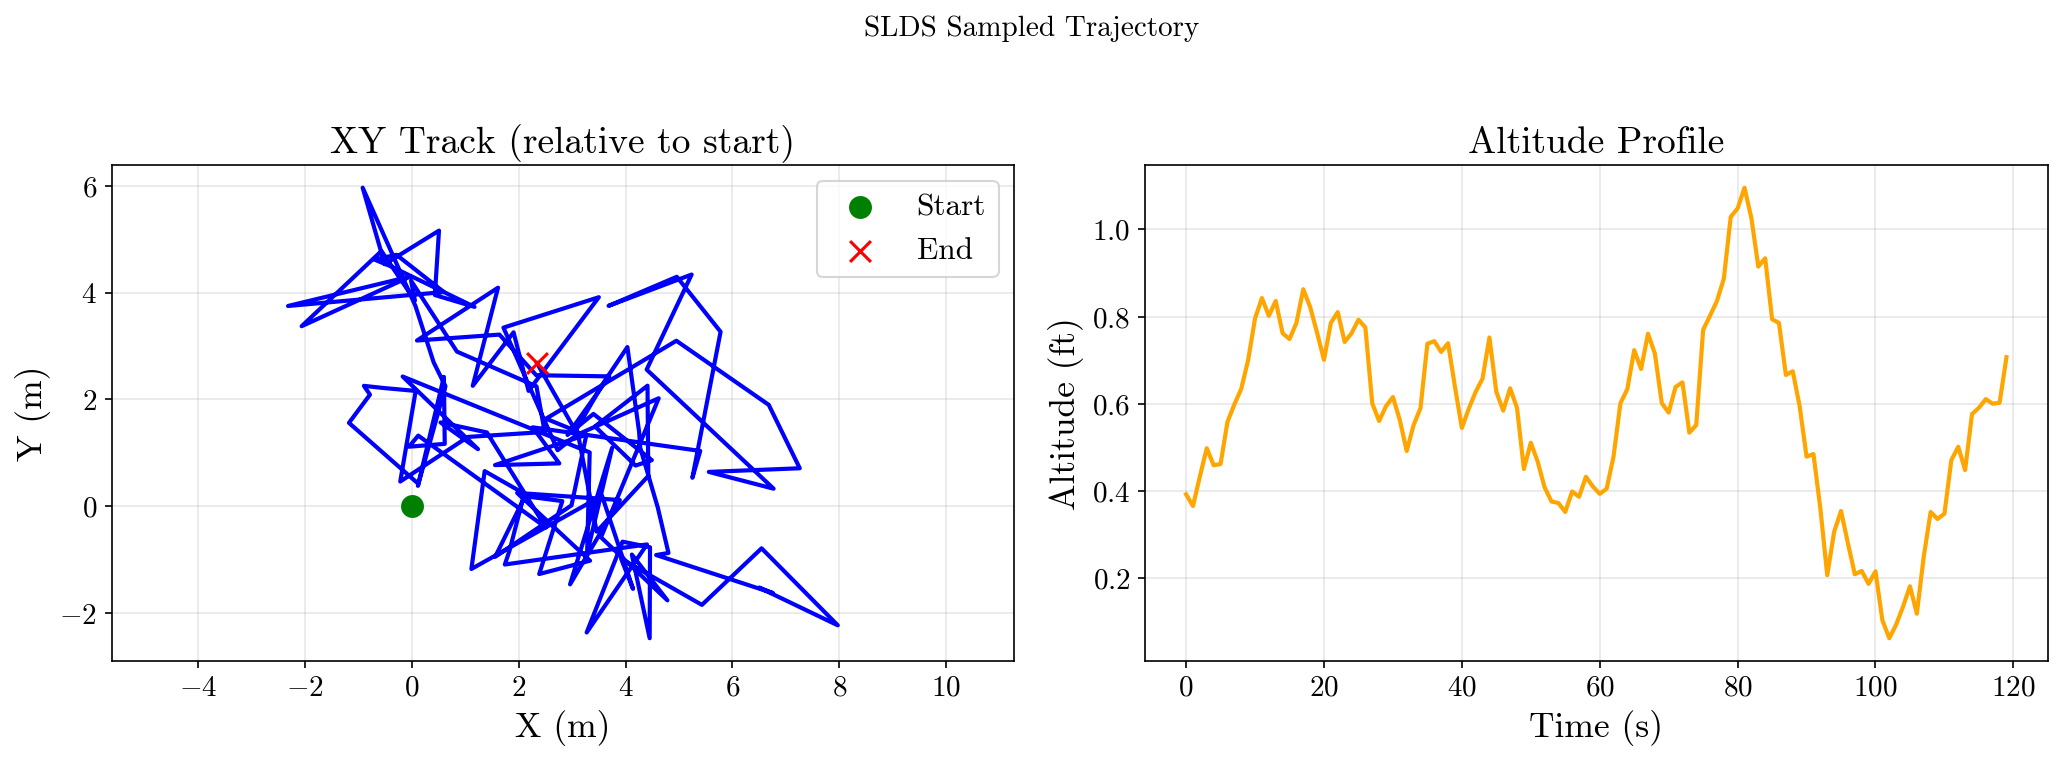

In [19]:
# Plot XY track and altitude
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# XY track
ax1.plot(integrated['x'], integrated['y'], linewidth=2, color='blue')
ax1.scatter(0, 0, color='green', s=100, marker='o', label='Start', zorder=5)
ax1.scatter(integrated['x'][-1], integrated['y'][-1], color='red', s=100, marker='x', label='End', zorder=5)
ax1.set_xlabel('X (m)')
ax1.set_ylabel('Y (m)')
ax1.set_title('XY Track (relative to start)')
ax1.axis('equal')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Altitude profile
ax2.plot(integrated['time'], integrated['altitude'], linewidth=2, color='orange')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Altitude (ft)')
ax2.set_title('Altitude Profile')
ax2.grid(True, alpha=0.3)

plt.suptitle('SLDS Sampled Trajectory', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Generate Multiple Trajectories (Ensemble)

**Goal**: Characterize uncertainty and variability by sampling **many trajectories** from the same initial condition.

**Expected behavior**: Trajectories should:
1. Share similar trends (same mode dynamics)
2. Show spread due to process noise $Q_k$
3. Form a "cone of uncertainty" that grows with time

**Comparison to DBN**: 
- DBN: Uncertainty from discrete bin selection (coarse)
- SLDS: Uncertainty from Gaussian covariance $Q_k$ (fine-grained)

In [20]:
# Generate ensemble of trajectories (choose fixed or switching mode)
N_SAMPLES = 100  # Number of trajectories
T_sample = 60  # 60 seconds

# Toggle between fixed and switching
USE_MODE_SWITCHING = False  # Set to True for longer trajectories or phase transitions

print(f"Generating {N_SAMPLES} trajectories...")
print(f"  Mode: {'SWITCHING' if USE_MODE_SWITCHING else 'FIXED'}")
trajectories = []
integrated_trajs = []
mode_sequences = []  # Will be populated if USE_MODE_SWITCHING=True

rng = np.random.default_rng(seed=42)

for i in tqdm(range(N_SAMPLES)):
    # Sample initial state (mode 0 for consistency)
    x_0 = sample_initial_state(model, initial_mode=0, rng=rng)
    
    # Generate trajectory
    if USE_MODE_SWITCHING:
        traj, modes = sample_trajectory_slds_with_switching(model, x_0, initial_mode=0, T=T_sample, rng=rng)
        mode_sequences.append(modes)
    else:
        traj = sample_trajectory_slds(model, x_0, mode=0, T=T_sample, rng=rng)
        mode_sequences.append(np.zeros(T_sample, dtype=int))  # all mode 0
    
    trajectories.append(traj)
    
    # Integrate to XY
    integrated = integrate_trajectory(traj, dt=1.0, initial_heading=0.0)
    integrated_trajs.append(integrated)

print(f"\n✓ Generated {N_SAMPLES} trajectories")
if USE_MODE_SWITCHING:
    avg_switches = np.mean([np.sum(np.diff(m) != 0) for m in mode_sequences])
    print(f"  Average mode switches per trajectory: {avg_switches:.1f}")

Generating 100 trajectories...
  Mode: FIXED


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 164.03it/s]


✓ Generated 100 trajectories


## Visualize Trajectory Ensemble

**Plots**:
1. **XY ensemble**: Overlay of all tracks
2. **Altitude ensemble**: Spread in vertical profiles
3. **Endpoint density**: 2D histogram of final positions

**Interpretation**: 
- Tight clustering → Low uncertainty (good model fit)
- Wide spread → High uncertainty (need more data or better model)

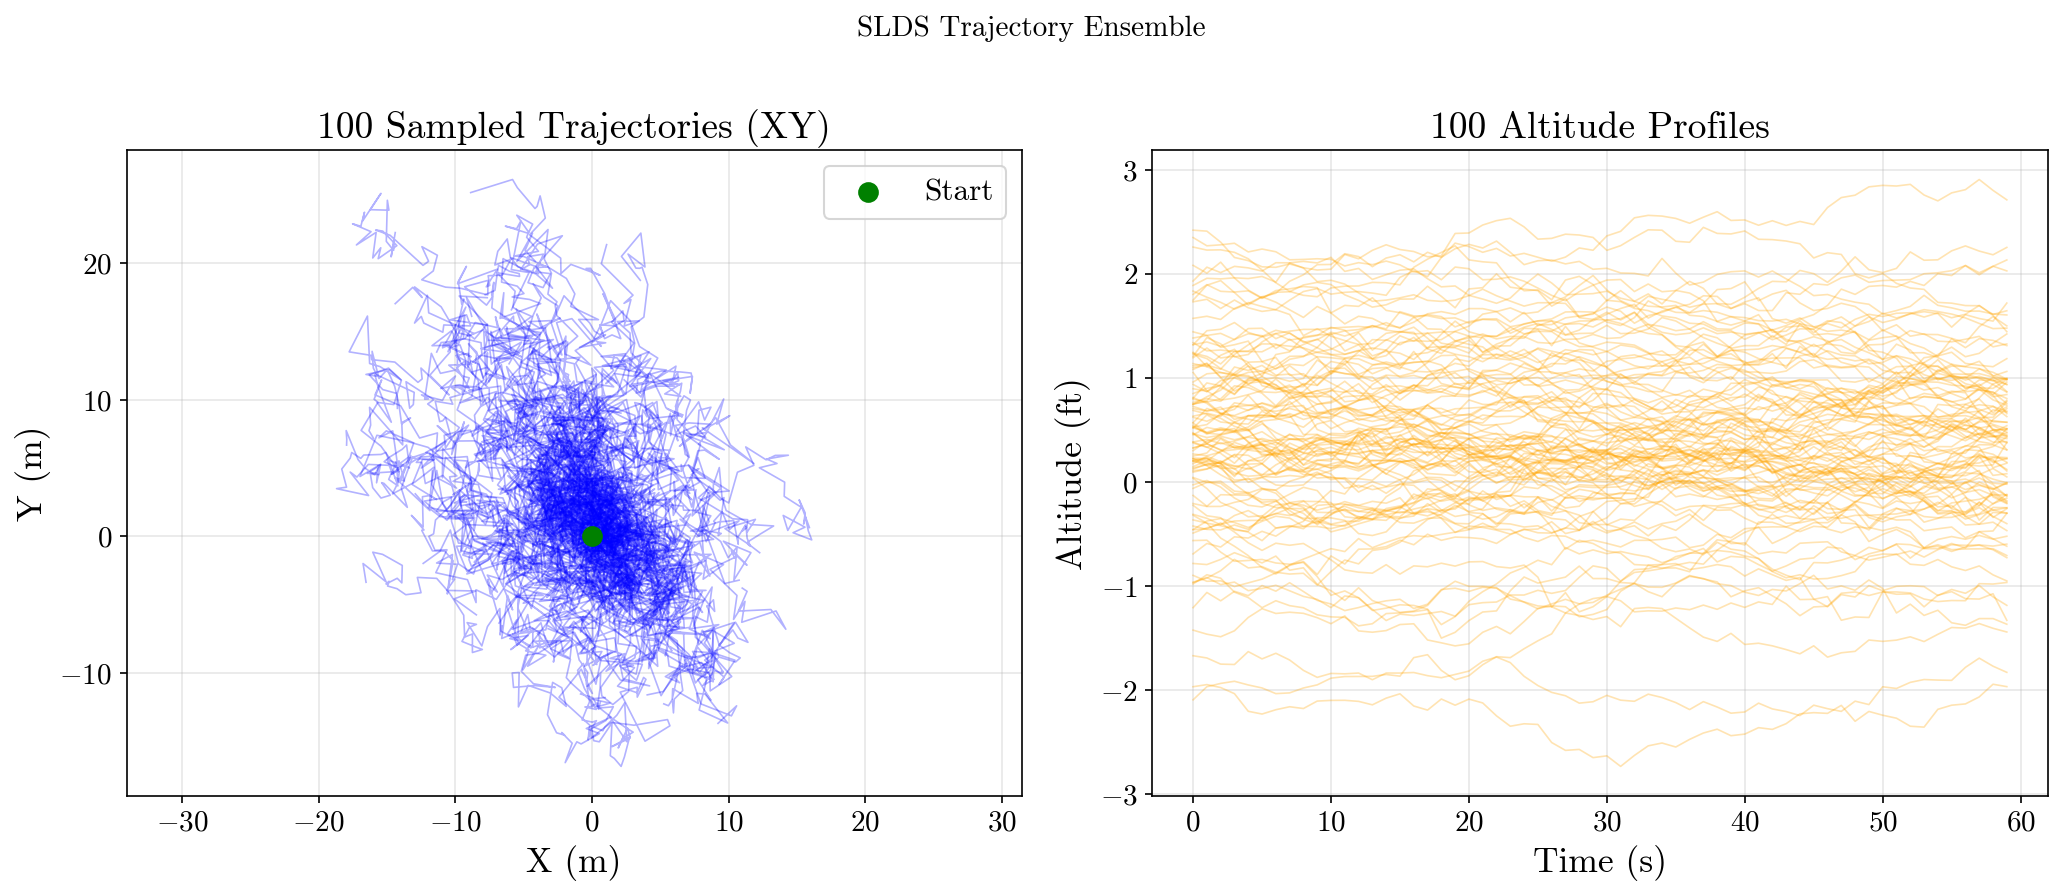

In [21]:
# Plot XY ensemble
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XY tracks
for itraj in integrated_trajs:
    axes[0].plot(itraj['x'], itraj['y'], alpha=0.3, linewidth=0.8, color='blue')
axes[0].scatter(0, 0, color='green', s=80, marker='o', label='Start', zorder=5)
axes[0].set_xlabel('X (m)')
axes[0].set_ylabel('Y (m)')
axes[0].set_title(f'{N_SAMPLES} Sampled Trajectories (XY)')
axes[0].axis('equal')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Altitude profiles
for itraj in integrated_trajs:
    axes[1].plot(itraj['time'], itraj['altitude'], alpha=0.3, linewidth=0.8, color='orange')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Altitude (ft)')
axes[1].set_title(f'{N_SAMPLES} Altitude Profiles')
axes[1].grid(True, alpha=0.3)

plt.suptitle('SLDS Trajectory Ensemble', y=1.00, fontsize=14)
plt.tight_layout()
plt.show()

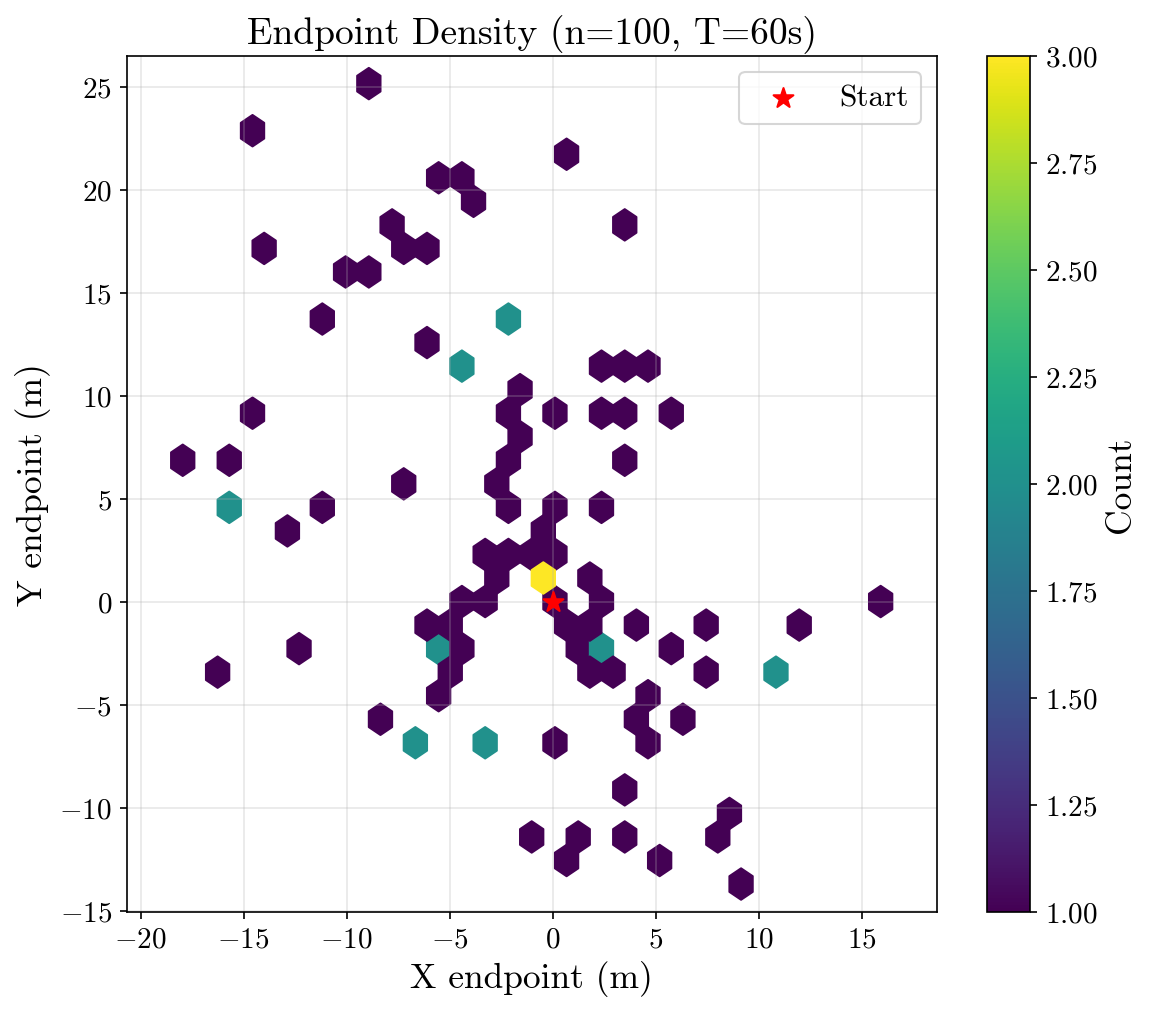


Endpoint statistics (relative to start):
  X: mean=-1.8 m, std=6.8 m
  Y: mean=3.0 m, std=9.0 m
  Distance: mean=10.2 m


In [22]:
# Plot endpoint density
endpoints_x = [itraj['x'][-1] for itraj in integrated_trajs]
endpoints_y = [itraj['y'][-1] for itraj in integrated_trajs]

fig, ax = plt.subplots(figsize=(8, 7))
h = ax.hexbin(endpoints_x, endpoints_y, gridsize=30, cmap='viridis', mincnt=1)
ax.scatter(0, 0, color='red', s=100, marker='*', label='Start', zorder=5)
ax.set_xlabel('X endpoint (m)')
ax.set_ylabel('Y endpoint (m)')
ax.set_title(f'Endpoint Density (n={N_SAMPLES}, T={T_sample}s)')
ax.axis('equal')
ax.grid(True, alpha=0.3)
ax.legend()
plt.colorbar(h, ax=ax, label='Count')
plt.tight_layout()
plt.show()

# Print statistics
print(f"\nEndpoint statistics (relative to start):")
print(f"  X: mean={np.mean(endpoints_x):.1f} m, std={np.std(endpoints_x):.1f} m")
print(f"  Y: mean={np.mean(endpoints_y):.1f} m, std={np.std(endpoints_y):.1f} m")
print(f"  Distance: mean={np.mean([np.sqrt(x**2 + y**2) for x, y in zip(endpoints_x, endpoints_y)]):.1f} m")

## Compare Distributions: SLDS vs Ground Truth

**Validation**: Compare sampled feature distributions to training data.

**Metrics**:
- Histograms of v, v_dot, psi_dot, h_dot
- Mean, std, quantiles

**Goal**: SLDS samples should **match** the training data distributions.

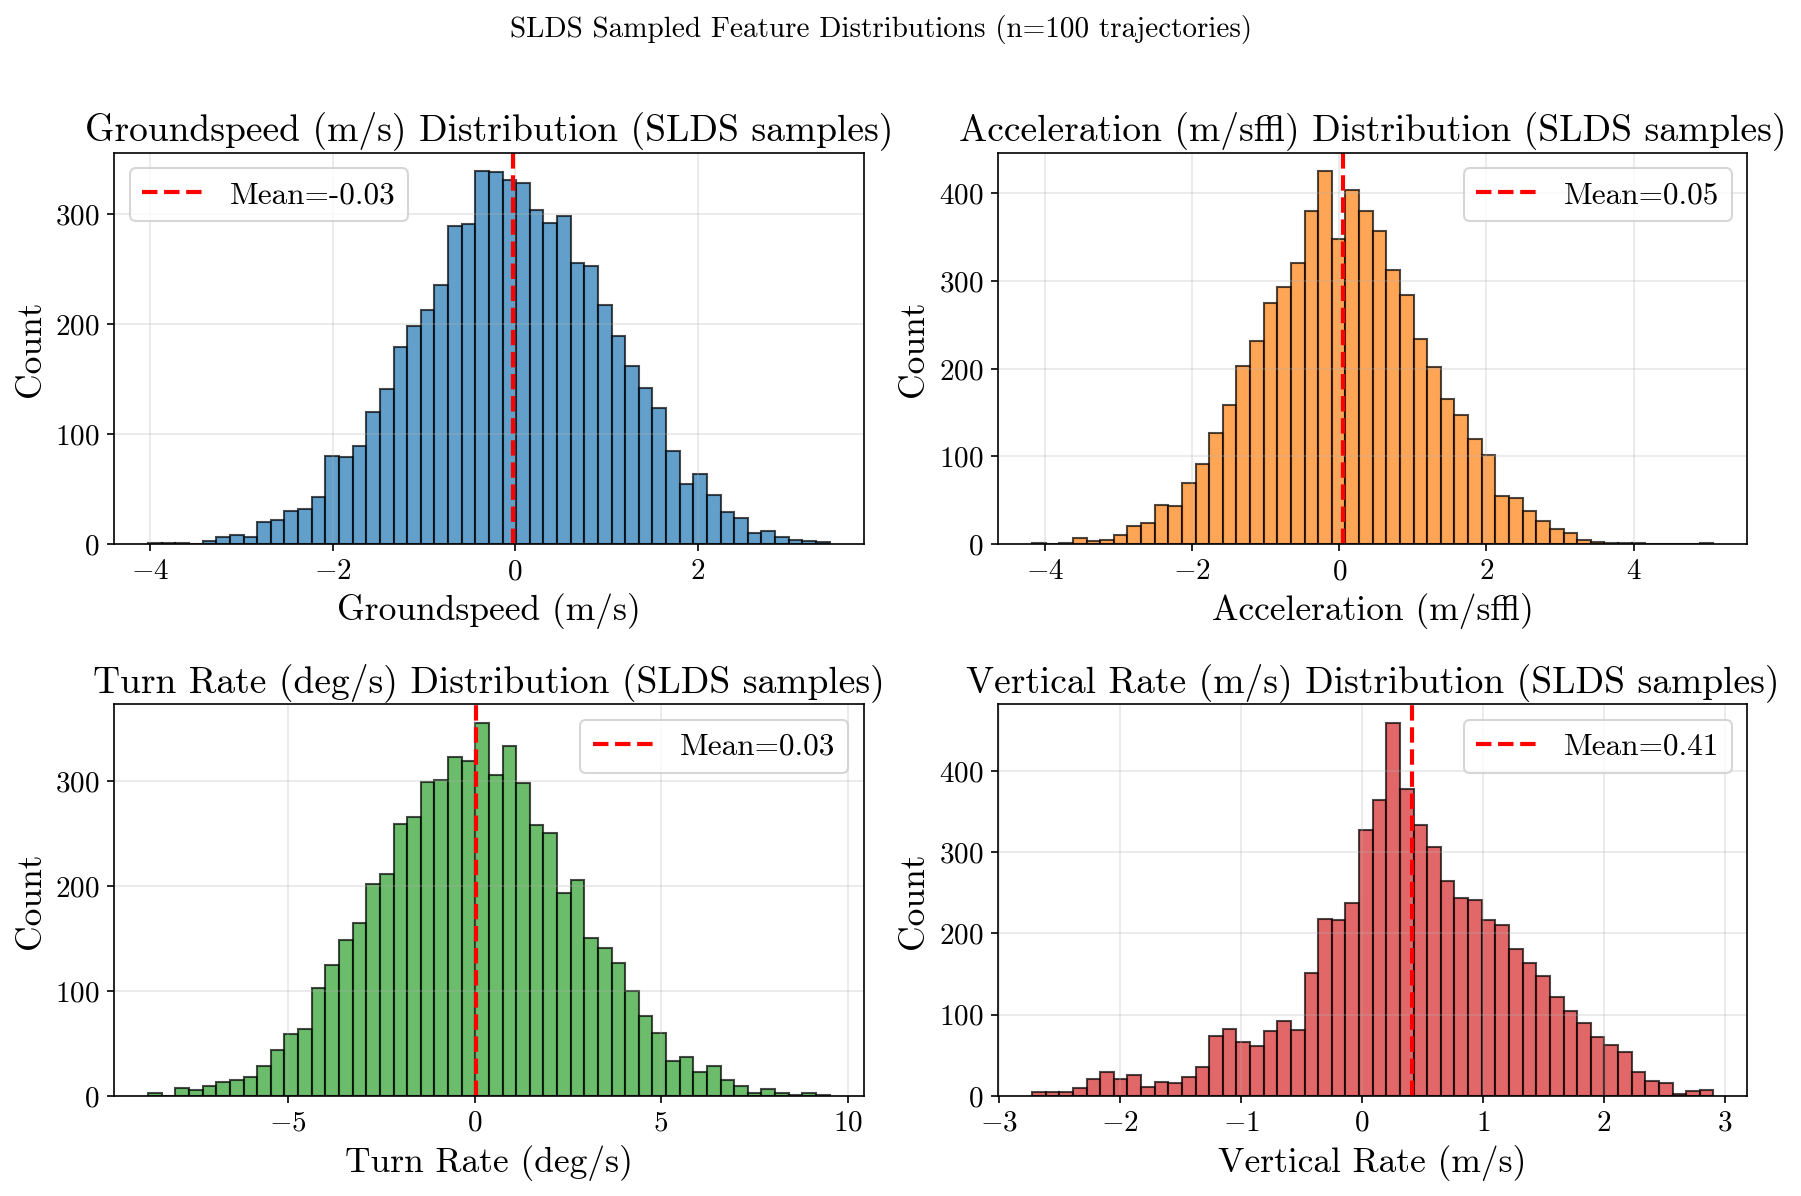


Feature Statistics (SLDS samples):
Groundspeed (m/s)        : mean= -0.029, std=  1.075, min= -4.019, max=  3.443
Acceleration (m/s²)      : mean=  0.051, std=  1.141, min= -4.174, max=  5.084
Turn Rate (deg/s)        : mean=  0.034, std=  2.641, min= -8.749, max=  9.519
Vertical Rate (m/s)      : mean=  0.414, std=  0.882, min= -2.730, max=  2.906


In [23]:
# Flatten all sampled trajectories
all_samples = np.concatenate(trajectories, axis=0)

# Plot distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

feature_labels = ['Groundspeed (m/s)', 'Acceleration (m/s²)', 'Turn Rate (deg/s)', 'Vertical Rate (m/s)']

for i, (ax, label) in enumerate(zip(axes, feature_labels)):
    vals = all_samples[:, i]
    ax.hist(vals, bins=50, alpha=0.7, edgecolor='black', color=f'C{i}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(f'{label} Distribution (SLDS samples)')
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    ax.axvline(np.mean(vals), color='red', linestyle='--', linewidth=2, label=f'Mean={np.mean(vals):.2f}')
    ax.legend()

plt.suptitle(f'SLDS Sampled Feature Distributions (n={N_SAMPLES} trajectories)', y=1.00, fontsize=14)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nFeature Statistics (SLDS samples):")
print("=" * 70)
for i, label in enumerate(feature_labels):
    vals = all_samples[:, i]
    print(f"{label:25s}: mean={np.mean(vals):7.3f}, std={np.std(vals):7.3f}, "
          f"min={np.min(vals):7.3f}, max={np.max(vals):7.3f}")

## Mode Switching During Trajectory
**How it works**:
1. At each timestep, sample next mode: $z_t \sim \text{Discrete}(\pi_{z_{t-1}, :})$
2. Use dynamics $A_{z_t}, b_{z_t}, Q_{z_t}$ for the sampled mode
3. Continue forward simulation with switched dynamics


MODE SWITCHING ANALYSIS

Transition Matrix Shape: (5, 5)
Number of modes (K): 5

Transition probabilities (sample of modes):
  Mode 0 → Most likely: 0 (0.530), 4 (0.285), 2 (0.095)
  Mode 1 → Most likely: 1 (0.841), 4 (0.153), 2 (0.005)
  Mode 2 → Most likely: 2 (0.940), 1 (0.046), 4 (0.013)
  Mode 3 → Most likely: 3 (0.870), 1 (0.094), 2 (0.031)
  Mode 4 → Most likely: 4 (0.930), 1 (0.070), 2 (0.001)


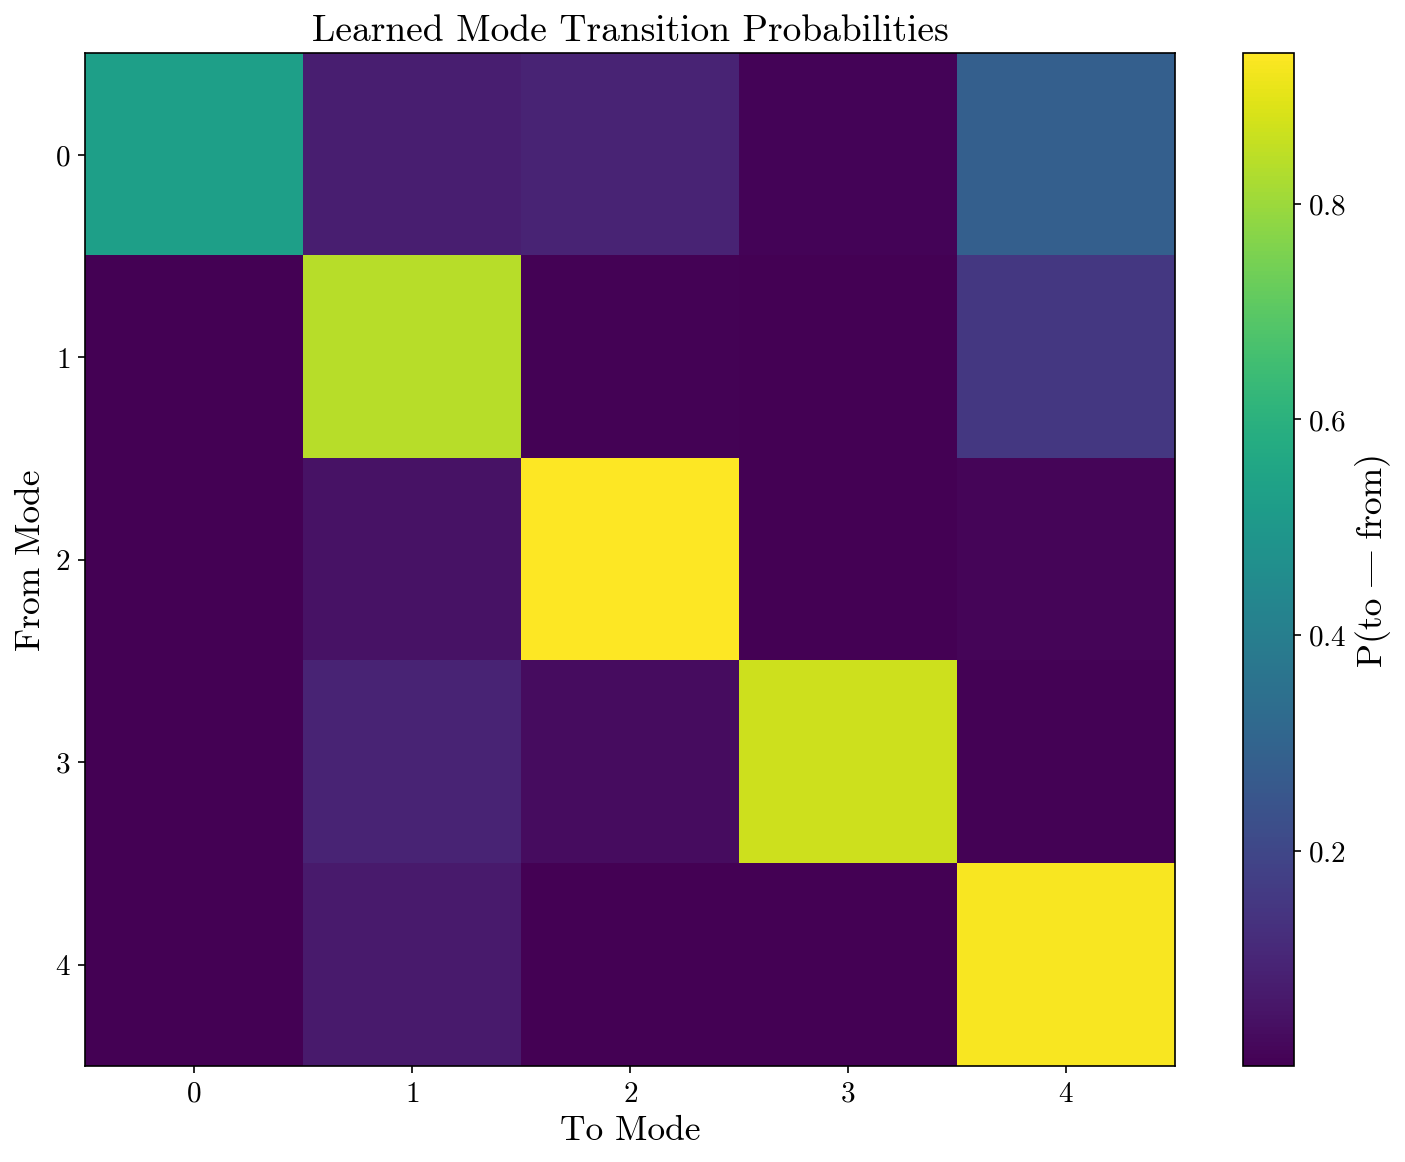


COMPARISON: Fixed Mode vs Mode Switching


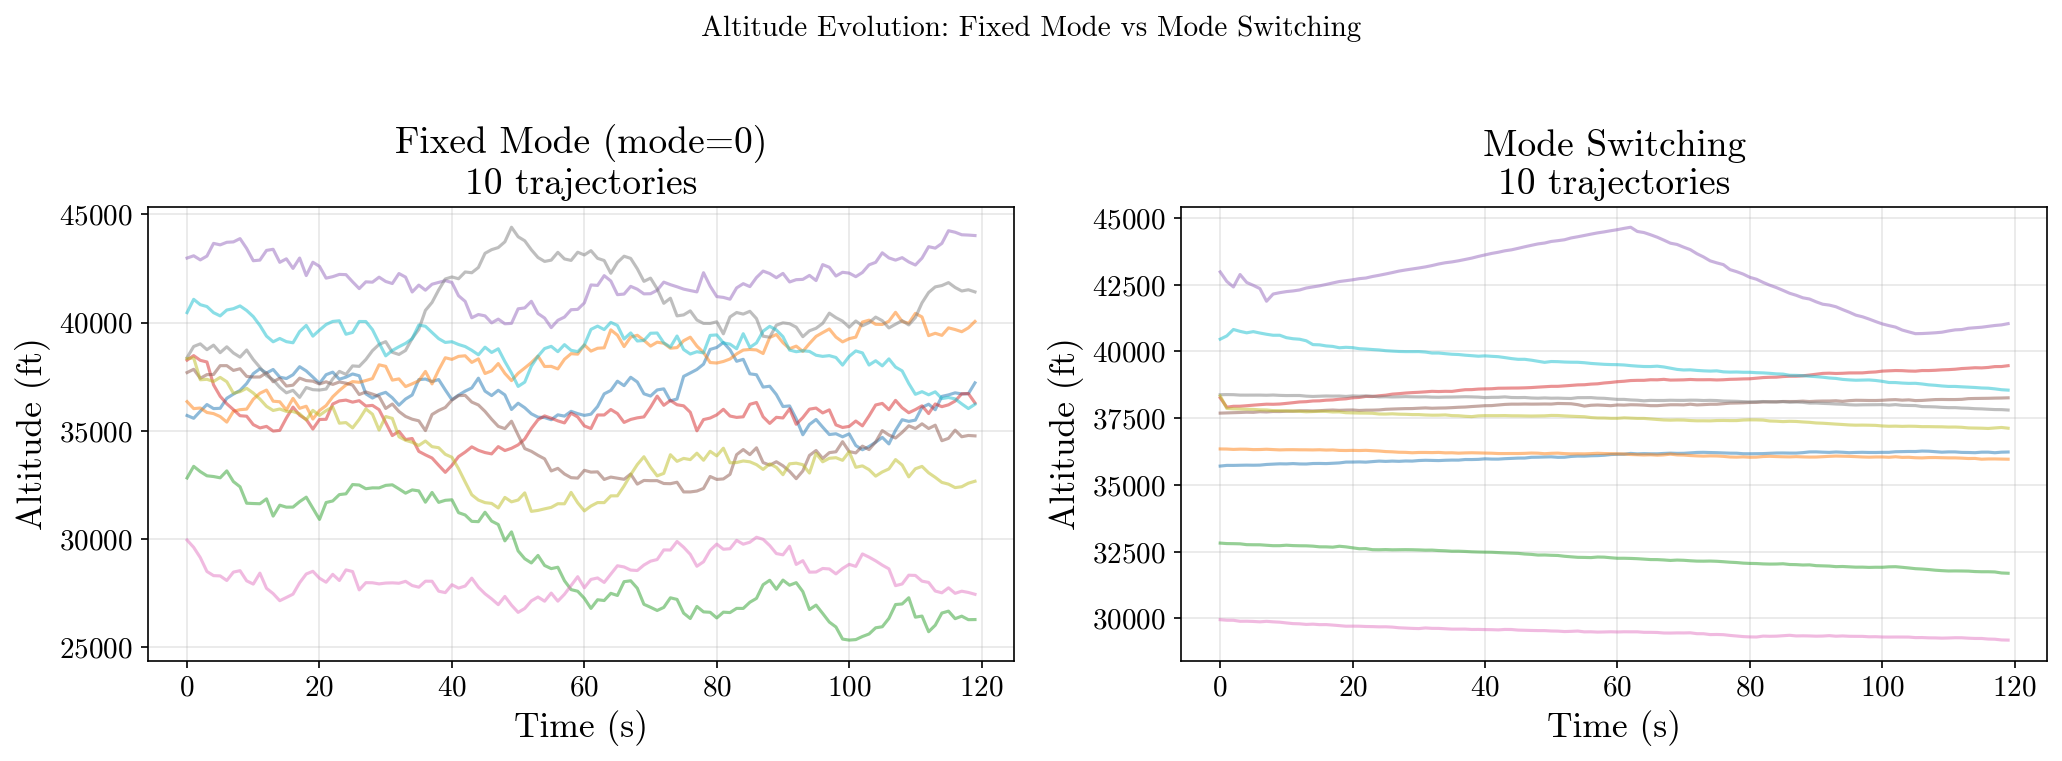

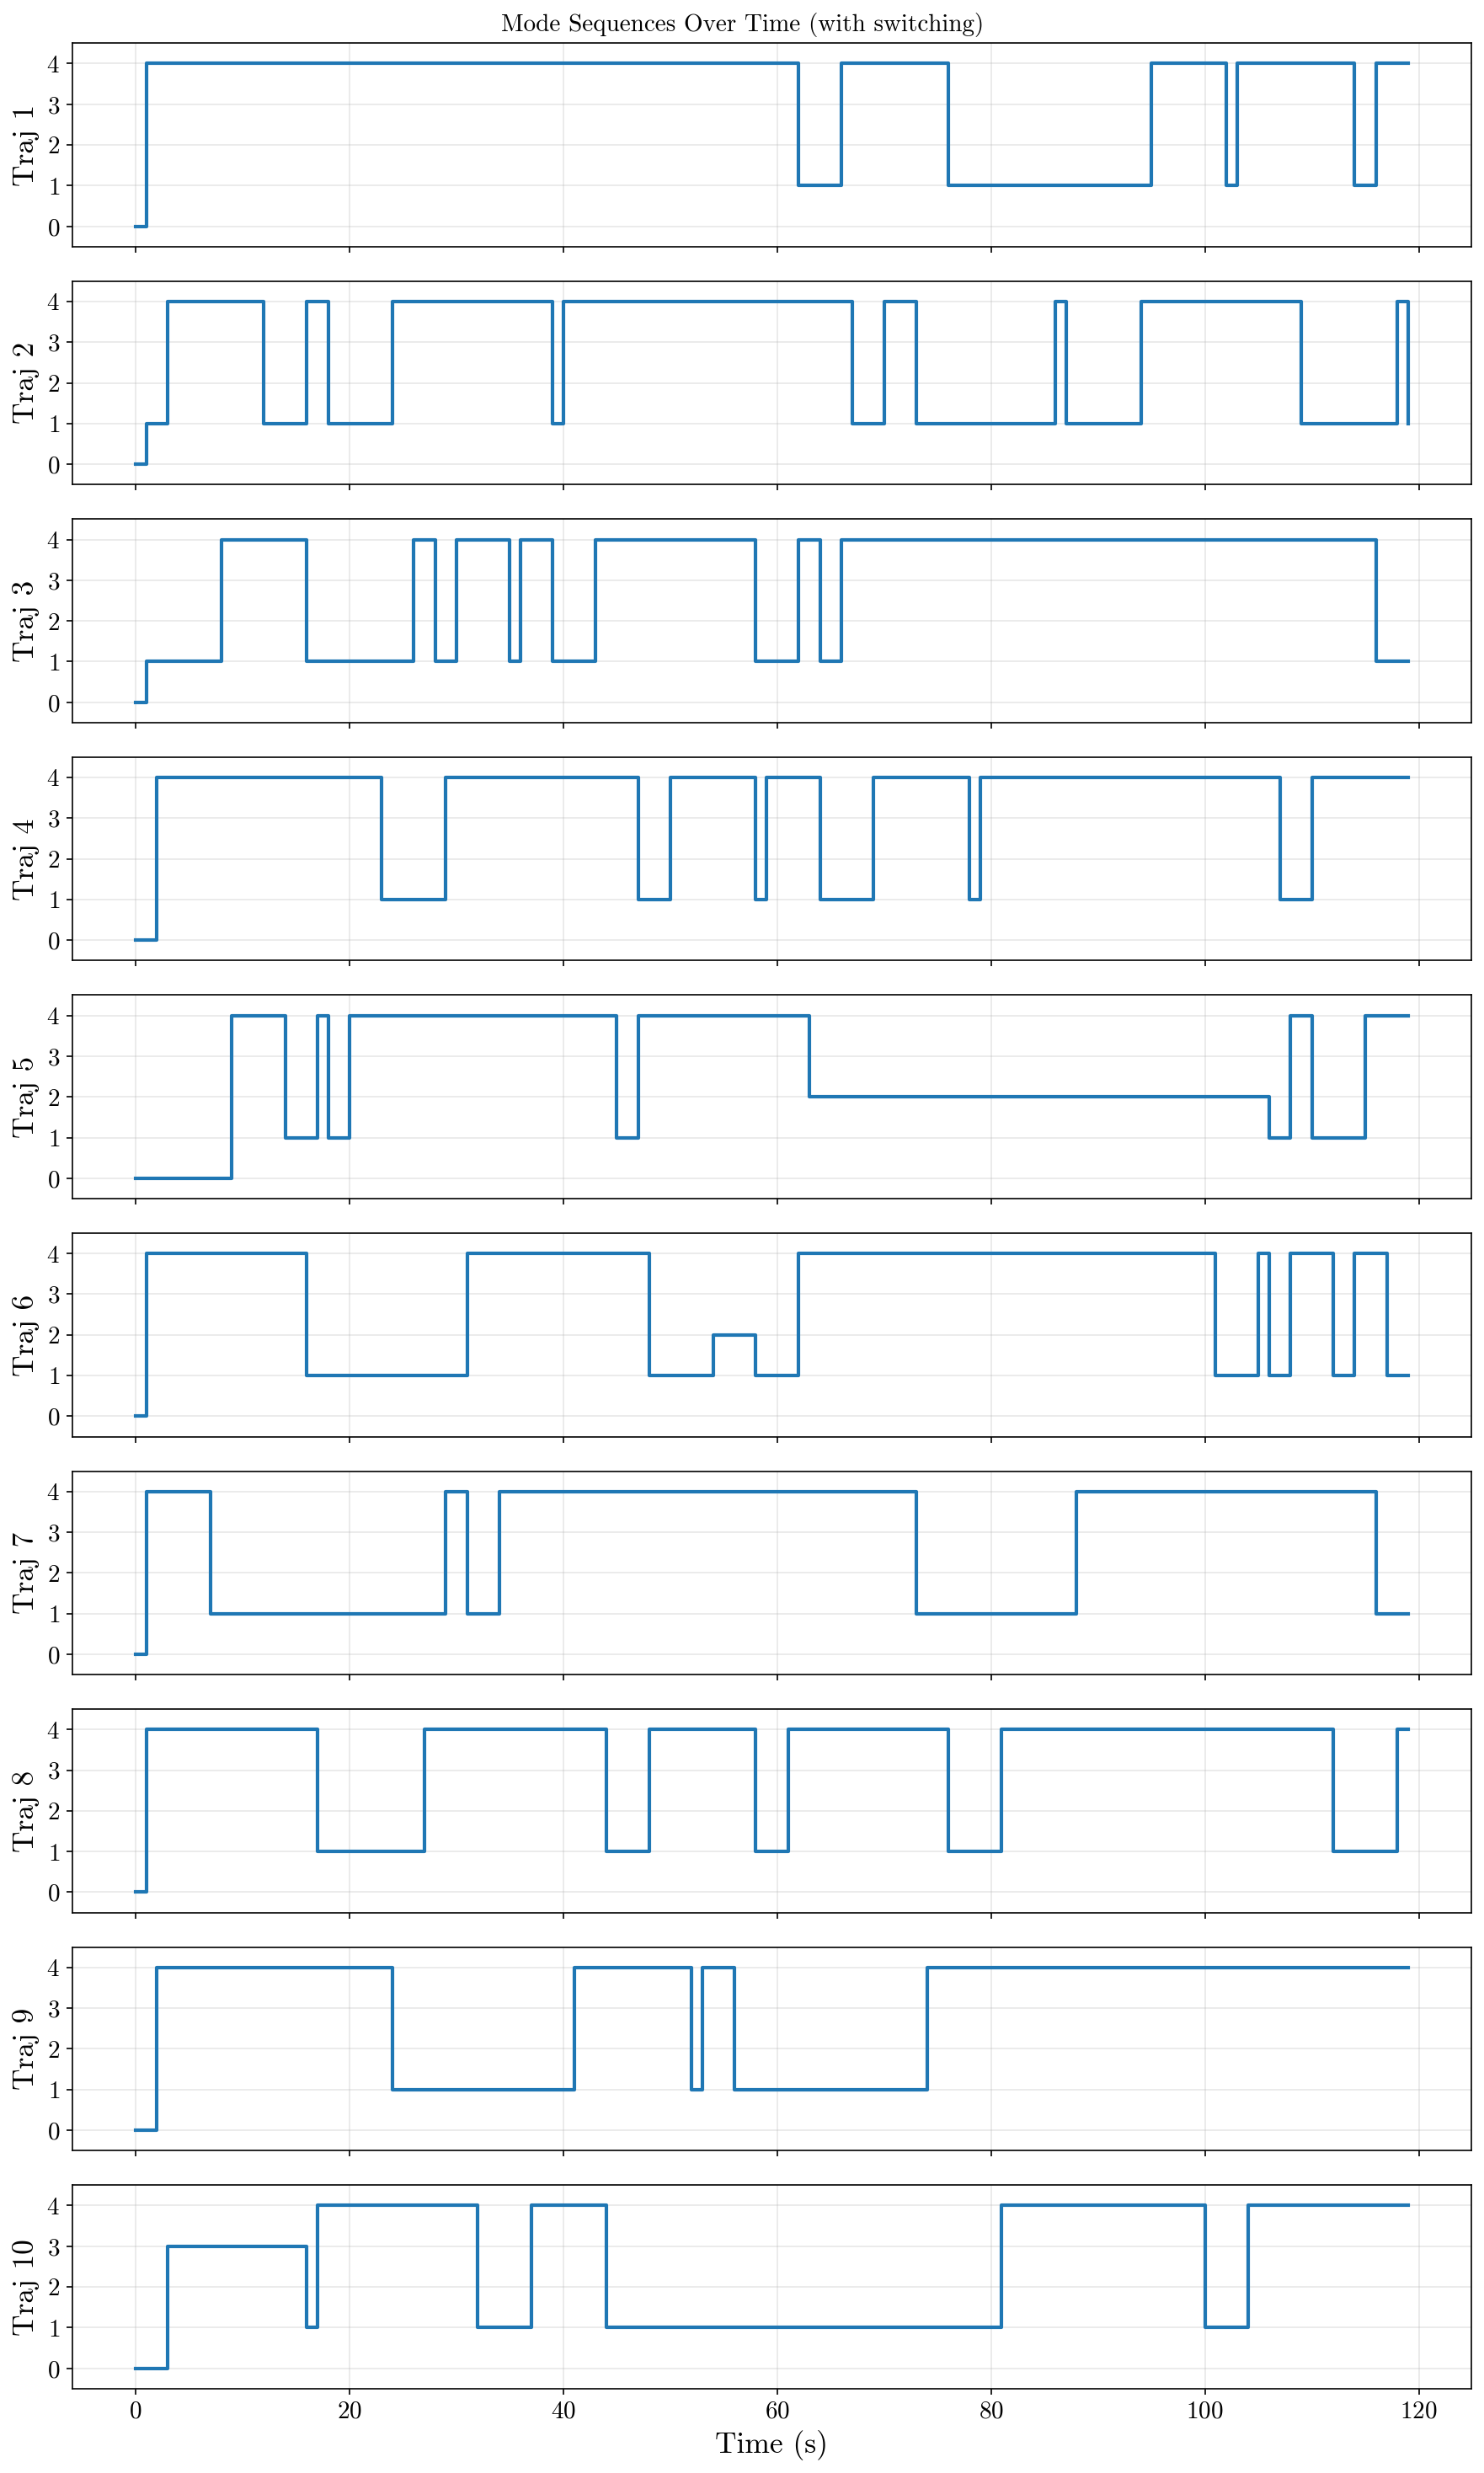


✓ Mode switching analysis complete!
  Average switches per trajectory: 11.5
  Max switches: 17
  Min switches: 7


In [28]:
# Visualize mode sequences and transition probabilities
print("\n" + "="*70)
print("MODE SWITCHING ANALYSIS")
print("="*70)

# Get transition matrix
trans_matrix = model.trans_distn.trans_matrix
K = trans_matrix.shape[0]

print(f"\nTransition Matrix Shape: {trans_matrix.shape}")
print(f"Number of modes (K): {K}")

# Show transition probabilities for a few modes
print("\nTransition probabilities (sample of modes):")
modes_to_show = min(5, K)
for k in range(modes_to_show):
    top_transitions = np.argsort(trans_matrix[k, :])[-3:][::-1]  # top 3 destinations
    print(f"  Mode {k} → Most likely: {top_transitions[0]} ({trans_matrix[k, top_transitions[0]]:.3f}), "
          f"{top_transitions[1]} ({trans_matrix[k, top_transitions[1]]:.3f}), "
          f"{top_transitions[2]} ({trans_matrix[k, top_transitions[2]]:.3f})")

# Plot transition matrix heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(trans_matrix, cmap='viridis', aspect='auto', interpolation='nearest')
ax.set_xlabel('To Mode')
ax.set_ylabel('From Mode')
ax.set_title('Learned Mode Transition Probabilities')
plt.colorbar(im, ax=ax, label='P(to | from)')
plt.tight_layout()
plt.show()

# Compare fixed-mode vs mode-switching trajectories
print("\n" + "="*70)
print("COMPARISON: Fixed Mode vs Mode Switching")
print("="*70)

# Generate 10 trajectories of each type
N_compare = 10
T_compare = 120  # 2 minutes to see more transitions
rng_compare = np.random.default_rng(seed=99)

fixed_trajs = []
switching_trajs = []
switching_modes = []

for i in range(N_compare):
    x_0_i = sample_initial_state(model, initial_mode=0, rng=rng_compare)
    
    # Fixed mode (return PHYSICAL units by passing scaler)
    traj_fixed = sample_trajectory_slds(model, x_0_i, mode=0, T=T_compare, rng=rng_compare, scaler=scaler)
    fixed_trajs.append(traj_fixed)
    
    # Mode switching (PHYSICAL units)
    traj_sw, modes_sw = sample_trajectory_slds_with_switching(model, x_0_i, initial_mode=0, T=T_compare, rng=rng_compare, scaler=scaler)
    switching_trajs.append(traj_sw)
    switching_modes.append(modes_sw)

# Plot altitude comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Fixed mode
for traj in fixed_trajs:
    ax1.plot(np.arange(T_compare), traj[:, -1], alpha=0.5, linewidth=1.5)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Altitude (ft)')
ax1.set_title(f'Fixed Mode (mode=0)\n{N_compare} trajectories')
ax1.grid(alpha=0.3)

# Mode switching
for traj in switching_trajs:
    ax2.plot(np.arange(T_compare), traj[:, -1], alpha=0.5, linewidth=1.5)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Altitude (ft)')
ax2.set_title(f'Mode Switching\n{N_compare} trajectories')
ax2.grid(alpha=0.3)

plt.suptitle('Altitude Evolution: Fixed Mode vs Mode Switching', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Show mode sequences over time
fig, axes = plt.subplots(N_compare, 1, figsize=(12, 2*N_compare), sharex=True)
if N_compare == 1:
    axes = [axes]

for i, (modes, ax) in enumerate(zip(switching_modes, axes)):
    ax.plot(np.arange(T_compare), modes, drawstyle='steps-post', linewidth=2, color='C0')
    ax.set_ylabel(f'Traj {i+1}')
    ax.set_ylim(-0.5, K-0.5)
    ax.grid(alpha=0.3)
    ax.set_yticks(range(0, K, max(1, K//10)))

axes[-1].set_xlabel('Time (s)')
plt.suptitle('Mode Sequences Over Time (with switching)', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n✓ Mode switching analysis complete!")
print(f"  Average switches per trajectory: {np.mean([np.sum(np.diff(m) != 0) for m in switching_modes]):.1f}")
print(f"  Max switches: {np.max([np.sum(np.diff(m) != 0) for m in switching_modes])}")
print(f"  Min switches: {np.min([np.sum(np.diff(m) != 0) for m in switching_modes])}")

## DBN Comparison: Versioned Data Load and Spatial Track
This section mirrors the DBN sampling notebook: we load the same versioned train/test splits (scaled arrays + scalers), pick a sample, reconstruct its past (input) and ground truth future lat/lon/altitude, and then overlay SLDS forward samples originating from the final input state for qualitative comparison.

Steps:
1. Load scaled arrays and scalers (VERSION / SUBVERSION).
2. Pick a sample index (random or fixed).
3. Extract past window (input) and future window (ground truth).
4. Convert lat/lon/alt to local XY coordinates (meters) using last input point as reference.
5. Use model dynamics: sample initial SLDS latent state from corresponding mode (or build from features) and simulate forward; overlay with ground truth.
6. Plot altitude vs time and XY track.

If scalers or arrays are unavailable, this cell will warn instead of failing.

In [25]:
import os, pickle, numpy as np, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

VERSION = "v4"
SUBVERSION = "v1"
base = f"/store/fusg/VT1/training/{VERSION}"
load = lambda split, kind: np.load(f"{base}/samples/{split}_{kind}_{SUBVERSION}.npy", allow_pickle=True).astype("float32")

try:
    with open(f"{base}/variables/scaler_in.pkl",  "rb") as f: scaler_in  = pickle.load(f)
    with open(f"{base}/variables/scaler_out.pkl", "rb") as f: scaler_out = pickle.load(f)
    test_var  = load("test",  "in_var")
    test_con  = load("test",  "in_con")
    test_out  = load("test",  "out")
    print("Loaded scalers + test arrays:", test_var.shape, test_out.shape)
except Exception as e:
    scaler_in = scaler_out = test_var = test_out = test_con = None
    print("⚠ Could not load versioned arrays:", e)

plt.rcParams.update({
    'text.usetex': False,
    'axes.formatter.use_mathtext' : True,
    'font.family': 'cmr10',
    'font.size': 15,
    'axes.labelsize': 17,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'figure.dpi': 150
})

# WGS84
WGS84_a = 6378137.0
WGS84_f = 1/298.257223563
WGS84_b = WGS84_a * (1 - WGS84_f)
WGS84_e = np.sqrt(1 - (WGS84_b**2)/(WGS84_a**2))

def lla_to_ecef(lat, lon, alt):
    lat_rad = np.radians(lat)
    lon_rad = np.radians(lon)
    N = WGS84_a / np.sqrt(1 - (WGS84_e * np.sin(lat_rad))**2)
    x = (N + alt) * np.cos(lat_rad) * np.cos(lon_rad)
    y = (N + alt) * np.cos(lat_rad) * np.sin(lon_rad)
    z = (N * (1 - WGS84_e**2) + alt) * np.sin(lat_rad)
    return x, y, z

def latlon_to_local_xy(lat_arr, lon_arr, lat0, lon0):
    delta_lat = np.array(lat_arr) - lat0
    delta_lon = np.array(lon_arr) - lon0
    x = delta_lon * 111320 * np.cos(np.radians(lat0))
    y = delta_lat * 111320
    return x, y

/home/fusg/.venv_slds/lib/python3.10/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.0 when using version 1.5.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loaded scalers + test arrays: (161880, 60, 16) (161880, 61, 16)


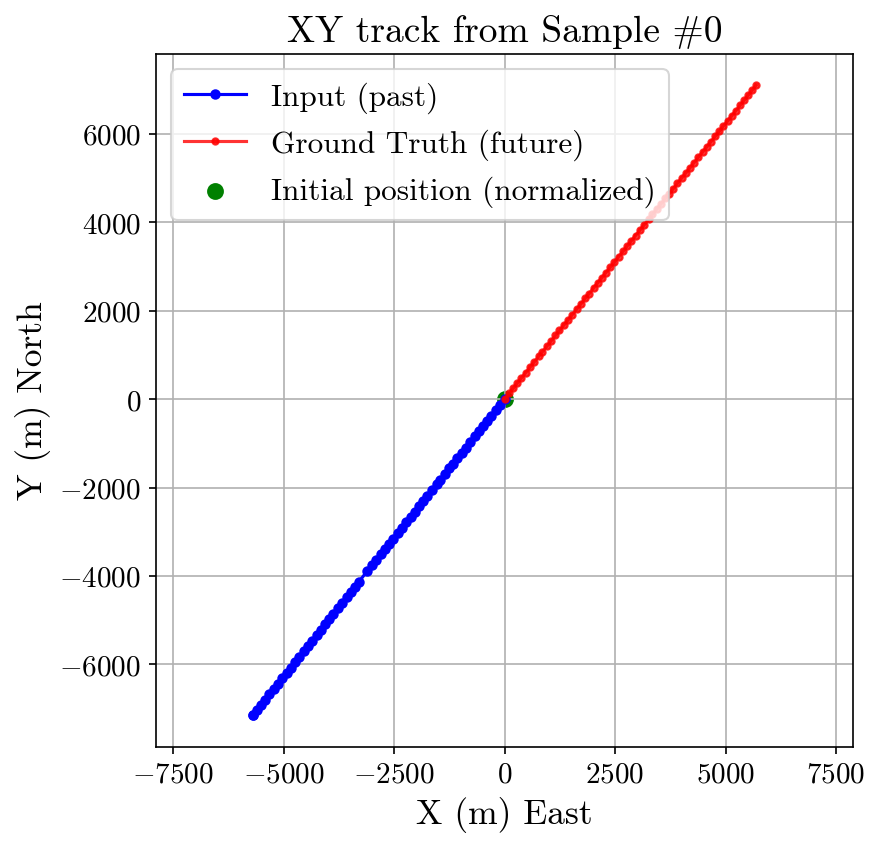

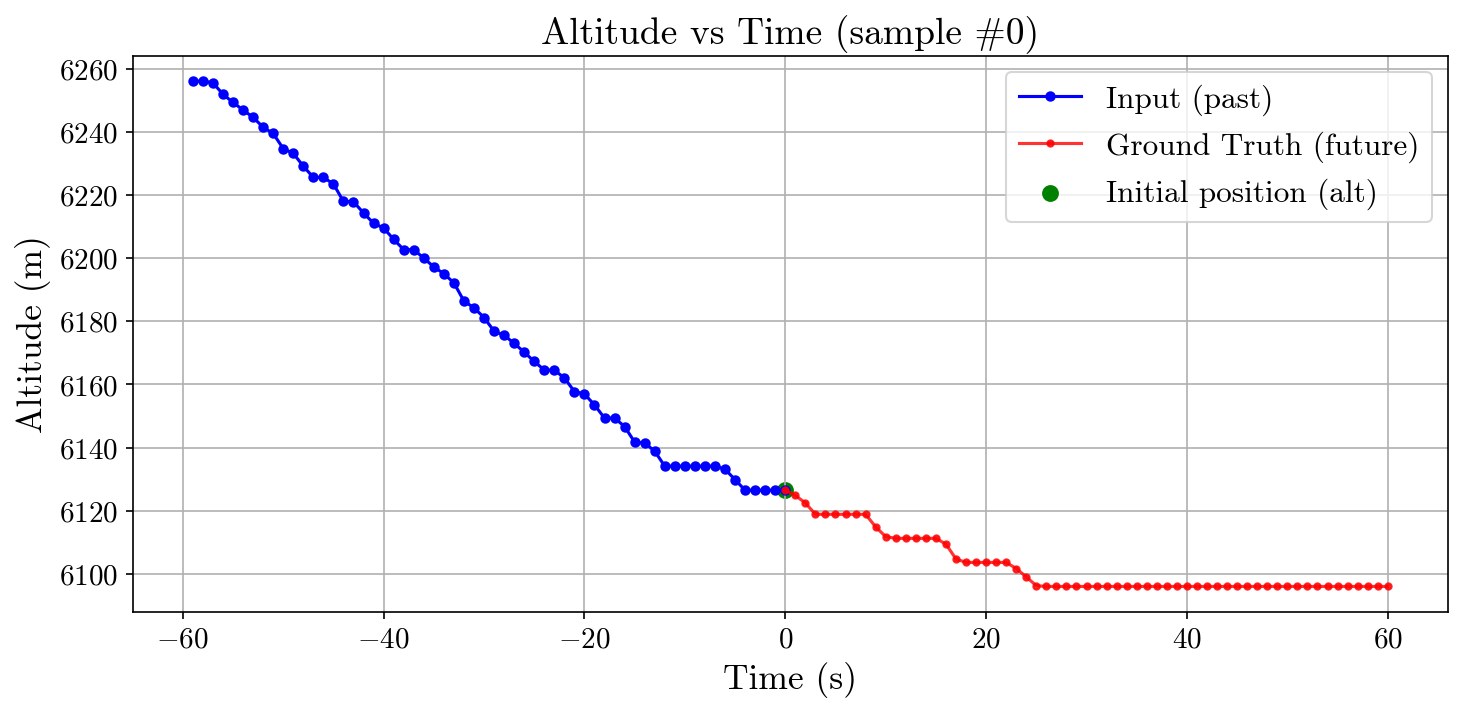

In [26]:
# Pick sample and overlay SLDS forward samples against ground truth (qualitative)
import numpy as np, matplotlib.pyplot as plt
if test_var is None:
    print("⚠ Skipping: versioned arrays are unavailable.")
else:
    # Choose sample
    sample_idx = 1384751 if 1384751 < len(test_var) else 0
    x_enc = test_var[sample_idx:sample_idx+1, :, :]   # (1, T_in, VARS)
    y_true = test_out[sample_idx, :, :]               # (T_out, features)

    # Unscale - now ALL 7 numerical features
    num_in_cols = [
        "latitude", "longitude", "altitude",
        "vertical_rate", "groundspeed",
        "acceleration", "turn_rate"
    ]
    input_unscaled = scaler_in.inverse_transform(x_enc[0, :, :len(num_in_cols)])
    true_unscaled  = scaler_out.inverse_transform(y_true[:, :len(num_in_cols)])

    # Convert to local XY (lat/lon only)
    ref_lat, ref_lon = input_unscaled[-1, 0], input_unscaled[-1, 1]
    input_x, input_y = latlon_to_local_xy(input_unscaled[:, 0], input_unscaled[:, 1], ref_lat, ref_lon)
    true_x,  true_y  = latlon_to_local_xy(true_unscaled[:, 0],  true_unscaled[:, 1],  ref_lat, ref_lon)

    # Plot XY past vs future
    plt.figure(figsize=(6,6))
    plt.plot(input_x, input_y, 'bo-', label='Input (past)', markersize=4)
    plt.plot(true_x,  true_y,  'r.-', label='Ground Truth (future)', alpha=0.8, markersize=6)
    plt.scatter(0.0, 0.0, color='green', s=50, label='Initial position (normalized)')
    plt.title(f"XY track from Sample #{sample_idx}")
    plt.xlabel("X (m) East")
    plt.ylabel("Y (m) North")
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()

    # Altitude vs time
    from math import floor
    def altitude_to_alt_m(ft):
        return ft * 0.3048
    T_in  = len(input_unscaled)
    T_out = len(true_unscaled)
    input_alt_m = altitude_to_alt_m(input_unscaled[:, 2])
    true_alt_m  = altitude_to_alt_m(true_unscaled[:, 2])
    plt.figure(figsize=(10,5))
    plt.plot(np.arange(-T_in+1, 1), input_alt_m, 'bo-', label='Input (past)', markersize=4)
    plt.plot(np.arange(0, T_out),  true_alt_m,  'r.-', label='Ground Truth (future)', alpha=0.8, markersize=6)
    plt.scatter(0, input_alt_m[-1], color='green', s=50, label='Initial position (alt)')
    plt.title(f'Altitude vs Time (sample #{sample_idx})')
    plt.xlabel('Time (s)')
    plt.ylabel('Altitude (m)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


🔍 DERIVED INITIAL STATE FROM LAST INPUT POINT:
   Phase: LEVEL (phase_idx=3)
   Groundspeed: 154.1 m/s
   Vertical rate: -0.975 m/s
   Altitude: 20100 ft
   Heading (from track): 38.6°
   vx, vy: 120.40, 96.21 m/s
   z-scores: [ 0.77  0.57 -0.31 -2.86]
   → Using SLDS mode: 3
   Using PURE derived state (no blending)


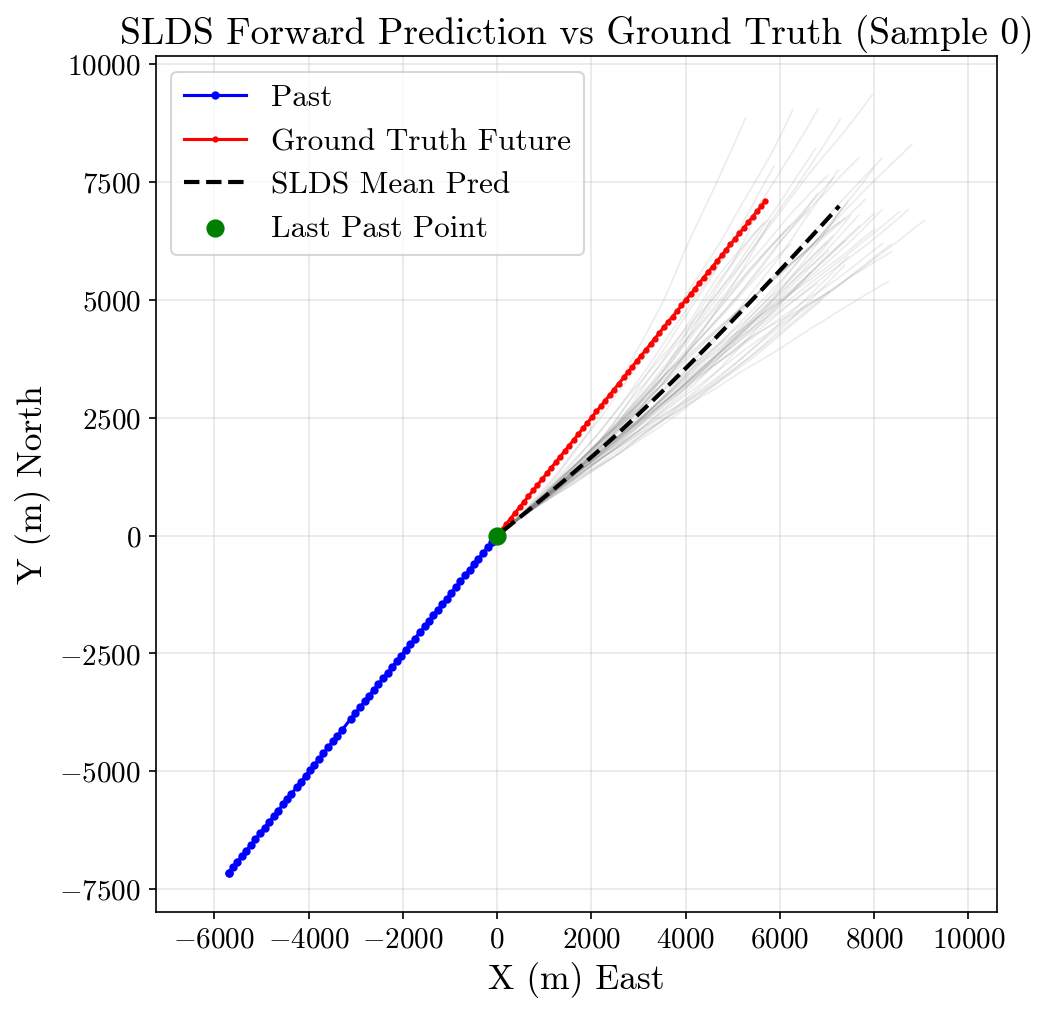

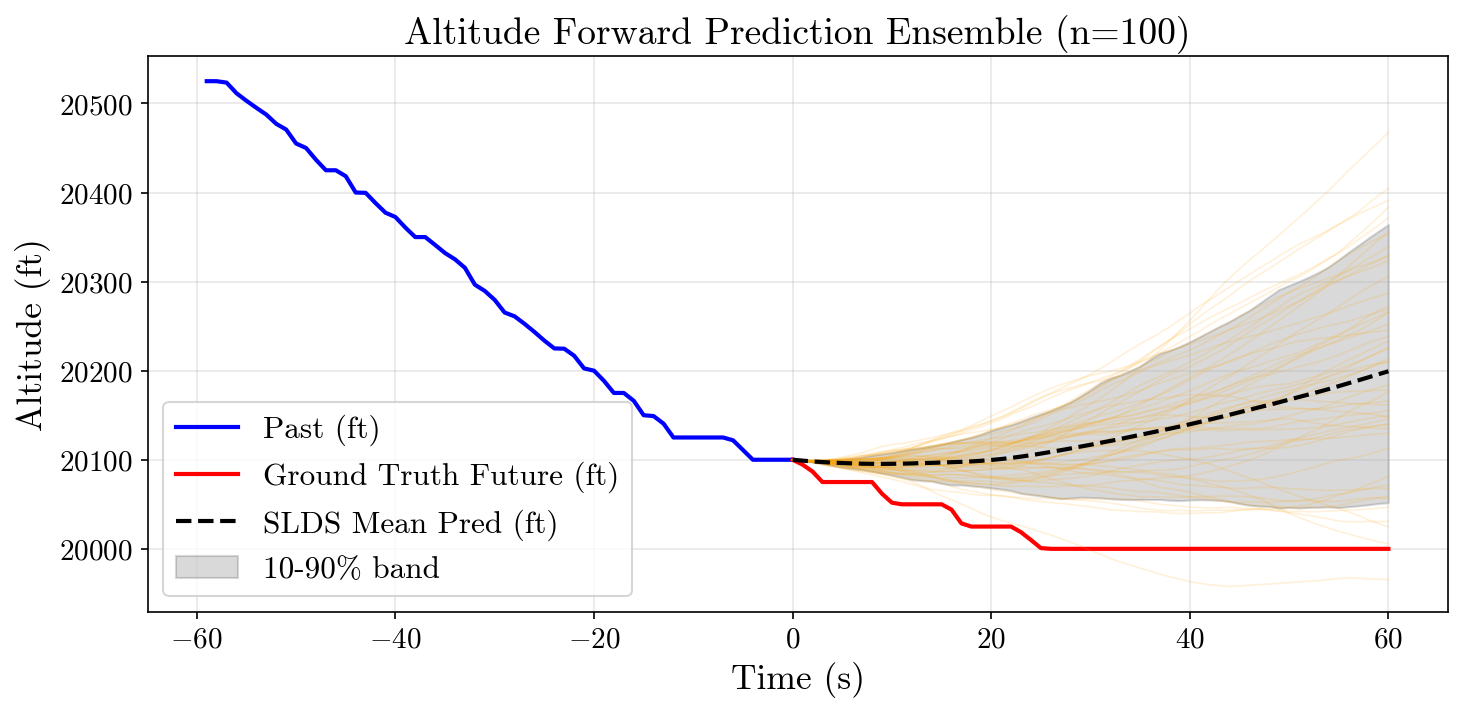


📊 PREDICTION METRICS:
   Mean XY RMSE: 972.0 m
   Mean Altitude MAE: 106.3 ft
   Final XY error: 1571.6 m
   Final Altitude error: 199.4 ft


In [30]:
# SLDS forward prediction from LAST INPUT POINT (like DBN trajectory generation)
import numpy as np, matplotlib.pyplot as plt
from math import atan2, sqrt
if test_var is None:
    print("⚠ Skipping forward prediction: test arrays unavailable.")
else:
    # Parameters
    horizon = true_unscaled.shape[0]  # match ground truth future length
    N_forward = 100  # ensemble size
    dt = 1.0

    last_point = input_unscaled[-1]  # Last timestep of input
    lat_last, lon_last, alt_last_ft, vrate_last_m_s, groundspeed_last, accel_last_raw, turnrate_last = last_point

    # Extract phase from one-hot encoding in test_var
    # Phase columns are at indices 11-15 (after track_sin/cos and hour_sin/cos)
    phase_onehot = test_var[sample_idx, -1, 11:16]  # [CLIMB, CRUISE, DESCENT, LEVEL, NA]
    phase_idx = np.argmax(phase_onehot)
    phase_names = ['CLIMB', 'CRUISE', 'DESCENT', 'LEVEL', 'NA']
    phase_name = phase_names[phase_idx]

    # Extract heading (track) from track_sin/track_cos in input
    # Columns 7-8 in test_var: track_sin, track_cos
    track_sin_last = test_var[sample_idx, -1, 7]
    track_cos_last = test_var[sample_idx, -1, 8]
    heading0 = atan2(track_sin_last, track_cos_last)  # Reconstruct heading (radians)

    # REPAIR 1: Recompute acceleration from last two groundspeed points (keeps consistency with legacy 5D)
    if len(input_unscaled) >= 2:
        accel_last = (input_unscaled[-1, 4] - input_unscaled[-2, 4]) / dt  # m/s^2
    else:
        accel_last = accel_last_raw

    # Determine SLDS feature dimensionality from scaler
    means = getattr(scaler, 'mean_', None)
    scales = getattr(scaler, 'scale_', None)
    n_feat = getattr(scaler, 'n_features_in_', len(means) if means is not None else None)

    # Build initial latent state in PHYSICAL units according to feature layout
    if n_feat == 4:
        # 4D layout: [vx, vy, vertical_rate, altitude]
        vx0 = groundspeed_last * np.cos(heading0)
        vy0 = groundspeed_last * np.sin(heading0)
        x0_latent_physical = np.array([
            vx0,                 # m/s east
            vy0,                 # m/s north
            vrate_last_m_s,      # m/s
            alt_last_ft          # ft
        ], dtype=float)

        # Clip to training-supported ranges (±3.5σ in physical space) if stats available
        if means is not None and scales is not None and len(means) >= 4:
            lo = means - 3.5 * scales
            hi = means + 3.5 * scales
            x0_latent_physical = np.clip(x0_latent_physical, lo[:4], hi[:4])

        # Diagnostics: z-scores of initial state
        if means is not None and scales is not None and len(means) >= 4:
            z0 = (x0_latent_physical - means[:4]) / scales[:4]
        else:
            z0 = None

    else:
        # 5D legacy layout: [v, v_dot, psi_dot, h_dot, altitude]
        x0_latent_physical = np.array([
            groundspeed_last,      # m/s
            accel_last,            # m/s² (recomputed)
            turnrate_last,         # deg/s
            vrate_last_m_s,        # m/s
            alt_last_ft            # ft
        ], dtype=float)

        # Clip to training-supported ranges (±3.5σ in physical space) if stats available
        if means is not None and scales is not None and len(means) >= 5:
            lo = means - 3.5 * scales
            hi = means + 3.5 * scales
            x0_latent_physical = np.clip(x0_latent_physical, lo[:5], hi[:5])

        # Diagnostics: z-scores of initial state
        if means is not None and scales is not None and len(means) >= 5:
            z0 = (x0_latent_physical - means[:5]) / scales[:5]
        else:
            z0 = None

    print(f"\n🔍 DERIVED INITIAL STATE FROM LAST INPUT POINT:")
    print(f"   Phase: {phase_name} (phase_idx={phase_idx})")
    print(f"   Groundspeed: {groundspeed_last:.1f} m/s")
    print(f"   Vertical rate: {vrate_last_m_s:.3f} m/s")
    print(f"   Altitude: {alt_last_ft:.0f} ft")
    print(f"   Heading (from track): {heading0 * 180/np.pi:.1f}°")
    if n_feat == 4:
        print(f"   vx, vy: {x0_latent_physical[0]:.2f}, {x0_latent_physical[1]:.2f} m/s")
    else:
        print(f"   Acceleration (recomputed): {accel_last:.3f} m/s², Turn rate: {turnrate_last:.3f} deg/s")
    if z0 is not None:
        print(f"   z-scores: {np.round(z0, 2)}")

    # Normalize using SLDS scaler for forward prediction
    x0_normalized = scaler.transform(x0_latent_physical.reshape(1, -1))[0]

    # Determine SLDS mode from phase (assume typecode_cluster=0)
    N_phases = metadata.get('N_phases', 5)
    typecode_cluster = 0
    initial_mode = typecode_cluster * N_phases + phase_idx

    print(f"   → Using SLDS mode: {initial_mode}")

    # Optional: Blend with learned initial distribution (for robustness)
    USE_BLENDING = False  # Set to True to blend with learned distribution
    if USE_BLENDING:
        sampled_x0 = sample_initial_state(model, initial_mode)
        blend_alpha = 0.1  # Small blending - trust observed state
        x0 = blend_alpha * sampled_x0 + (1 - blend_alpha) * x0_normalized
        print(f"   Blending with learned distribution (alpha={blend_alpha})")
    else:
        x0 = x0_normalized
        print(f"   Using PURE derived state (no blending)")

    # ============================================================================
    # Generate ensemble of forward predictions
    # ============================================================================
    forward_trajs = []
    forward_integrated = []
    rng_pred = np.random.default_rng(seed=123)

    ENFORCE_ALT_INTEGRATION = True  # enforce physical altitude consistency from h_dot
    USE_MODE_SWITCHING = False      # keep the phase fixed for short horizons

    for i in range(N_forward):
        if USE_MODE_SWITCHING:
            traj_f_phys, modes_f = sample_trajectory_slds_with_switching(
                model, x0, initial_mode=initial_mode, T=horizon, rng=rng_pred, scaler=scaler
            )
        else:
            traj_f_phys = sample_trajectory_slds(
                model, x0, mode=initial_mode, T=horizon, rng=rng_pred, scaler=scaler
            )

        # Enforce altitude integration from vertical rate
        if ENFORCE_ALT_INTEGRATION:
            D_traj = traj_f_phys.shape[1]
            vr_idx = 2 if D_traj == 4 else 3
            alt_idx = 3 if D_traj == 4 else 4
            alt_series = alt_last_ft + np.cumsum(np.concatenate([[0.0], traj_f_phys[:-1, vr_idx] * dt]))
            traj_f_phys = traj_f_phys.copy()
            traj_f_phys[:, alt_idx] = alt_series

        # Integrate to XY/heading using layout-aware integrator
        integ_f = integrate_trajectory(traj_f_phys, dt=dt, initial_heading=heading0)
        forward_trajs.append(traj_f_phys)
        forward_integrated.append(integ_f)

    # Stack for stats
    alt_matrix_ft = np.stack([it['altitude'] for it in forward_integrated], axis=0)
    x_matrix = np.stack([it['x'] for it in forward_integrated], axis=0)
    y_matrix = np.stack([it['y'] for it in forward_integrated], axis=0)
    mean_x = x_matrix.mean(axis=0)
    mean_y = y_matrix.mean(axis=0)
    mean_alt_ft = alt_matrix_ft.mean(axis=0)
    p10_alt = np.percentile(alt_matrix_ft, 10, axis=0)
    p90_alt = np.percentile(alt_matrix_ft, 90, axis=0)

    # Convert ground truth future lat/lon to local XY for overlay
    gt_x, gt_y = latlon_to_local_xy(true_unscaled[:, 0], true_unscaled[:, 1], ref_lat, ref_lon)
    gt_alt_ft = true_unscaled[:, 2]

    # ============================================================================
    # PLOT: XY trajectory overlay
    # ============================================================================
    plt.figure(figsize=(7, 7))
    # Past
    plt.plot(input_x, input_y, 'bo-', label='Past', markersize=3)
    # Ground truth future
    plt.plot(gt_x, gt_y, 'r.-', label='Ground Truth Future', markersize=4)
    # Ensemble (thin)
    for i in range(min(N_forward, 50)):
        plt.plot(x_matrix[i], y_matrix[i], color='gray', alpha=0.15, linewidth=0.8)
    # Mean prediction
    plt.plot(mean_x, mean_y, 'k--', linewidth=2, label='SLDS Mean Pred')
    plt.scatter(0, 0, c='green', s=60, label='Last Past Point', zorder=10)
    plt.title(f'SLDS Forward Prediction vs Ground Truth (Sample {sample_idx})')
    plt.xlabel('X (m) East')
    plt.ylabel('Y (m) North')
    plt.axis('equal')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ============================================================================
    # PLOT: Altitude profile overlay
    # ============================================================================
    t_past = np.arange(-len(input_unscaled) + 1, 1)
    t_future = np.arange(horizon)

    plt.figure(figsize=(10, 5))
    plt.plot(t_past, input_unscaled[:, 2], 'b-', label='Past (ft)', linewidth=2)
    plt.plot(t_future, gt_alt_ft, 'r-', label='Ground Truth Future (ft)', linewidth=2)
    
    # Ensemble (thin)
    for i in range(min(N_forward, 50)):
        plt.plot(t_future, alt_matrix_ft[i], color='orange', alpha=0.15, linewidth=0.8)

    plt.plot(t_future, mean_alt_ft, 'k--', label='SLDS Mean Pred (ft)', linewidth=2)
    plt.fill_between(t_future, p10_alt, p90_alt, color='k', alpha=0.15, label='10-90% band')
    plt.xlabel('Time (s)')
    plt.ylabel('Altitude (ft)')
    plt.title(f'Altitude Forward Prediction Ensemble (n={N_forward})')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ============================================================================
    # Error metrics
    # ============================================================================
    xy_err = np.sqrt((mean_x - gt_x)**2 + (mean_y - gt_y)**2)
    alt_err = np.abs(mean_alt_ft - gt_alt_ft)

    print(f"\n📊 PREDICTION METRICS:")
    print(f"   Mean XY RMSE: {np.sqrt(np.mean(xy_err**2)):.1f} m")
    print(f"   Mean Altitude MAE: {np.mean(alt_err):.1f} ft")
    print(f"   Final XY error: {np.sqrt((mean_x[-1]-gt_x[-1])**2 + (mean_y[-1]-gt_y[-1])**2):.1f} m")
    print(f"   Final Altitude error: {alt_err[-1]:.1f} ft")